# Dependancies

In [137]:
!pip install kagglehub numpy pandas matplotlib seaborn scikit-learn imbalanced-learn

In [138]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from torch.utils.data import TensorDataset, DataLoader

NUM_FOLDS = 4
RANDOM_STATE = 42
SAMPLE_SIZE = 500000 # Edit for final run, 300000-500000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") #used to automatically detect GPU or default to CPU otherwise

### Metric Helpers
These are just some metric helpers that we can use of need be

In [139]:
def compute_metrics(y_true, y_pred, y_prob):
  return{
      "precision": precision_score(y_true, y_pred),
      "recall": recall_score(y_true, y_pred),
      "f1": f1_score(y_true, y_pred),
      "roc_auc": roc_auc_score(y_true, y_prob),
      "mcc": matthews_corrcoef(y_true, y_pred),
  }

def save_fig(fig, name):
    path = os.path.join(RESULTS, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def confusion_matrices(splits, Xfeatures, y, train_predict_fn, model_name, file):
    fig, axes = plt.subplots(1, len(splits), figsize=(5 * len(splits), 4))
    if len(splits) == 1:
        axes = [axes]

    for i, (train_idx, test_idx) in enumerate(splits):
        y_pred = train_predict_fn(train_idx, test_idx)
        y_test = y.iloc[test_idx]
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                    xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
        axes[i].set_title(f"Split {i + 1}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")

    fig.suptitle(f"{model_name} - Confusion Matrices", fontweight="bold")
    fig.tight_layout()
    save_fig(fig, file)


def plot_roc_curve(splits, Xfeatures, y, train_predict_proba_fn, model_name, file):
    fig, ax = plt.subplots(figsize=(8, 6))

    for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
        y_prob = train_predict_proba_fn(train_idx, test_idx)
        y_test = y.iloc[test_idx]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"Split {split_num} (AUC = {auc_val:.3f})")

    ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{model_name} ROC Curve")
    ax.legend(loc="lower right")
    fig.tight_layout()
    save_fig(fig, file)


def plot_metrics_bar(results_df, splits, model_name, file):
    fig, ax = plt.subplots(figsize=(10, 5))

    metrics_to_plot = ["precision", "recall", "f1", "roc_auc", "mcc"]
    x = np.arange(len(splits))
    bar_width = 0.15
    colors = ["#056517", "#de1a24", "#3b75e9", "#cad5ed", "#2832c4"]

    for i, metric in enumerate(metrics_to_plot):
        vals = results_df[metric].values
        ax.bar(x + i * bar_width, vals, bar_width, label=metric, color=colors[i])

    ax.set_xlabel("Split", fontsize=12, fontweight="bold")
    ax.set_ylabel("Score", fontsize=12, fontweight="bold")
    ax.set_title(f"{model_name} Metrics", fontsize=14, fontweight="bold")
    ax.set_xticks(x + bar_width * (len(metrics_to_plot) - 1) / 2)
    ax.set_xticklabels([f"Split {i + 1}" for i in range(len(splits))])
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right")
    fig.tight_layout()
    save_fig(fig, file)


def plot_feature_coefficients(coefs, feature_names, model_name, split_label, file, top_n=15):
    fig, ax = plt.subplots(figsize=(12, 6))

    feature_names = np.array(feature_names)
    sorted_idx = np.argsort(np.abs(coefs))[::-1]
    top_idx = sorted_idx[:top_n]

    top_coefs = coefs[top_idx]
    top_names = feature_names[top_idx]
    bar_colors = ["#de1a24" if c < 0 else "#056517" for c in top_coefs]

    ax.barh(top_names, top_coefs, color=bar_colors, edgecolor="black")
    ax.set_xlabel("Coefficient Value", fontsize=12)
    ax.set_title(f"{model_name} - Top {top_n} Coefficients ({split_label})",
                 fontsize=14, fontweight="bold")
    ax.invert_yaxis()
    fig.tight_layout()
    save_fig(fig, file)

def _make_cached_predictor(fold_predictions, key, n_folds):
    preds = [fold_predictions[i + 1][key] for i in range(n_folds)]
    call_idx = [0]
    def predictor(train_idx, test_idx):
        result = preds[call_idx[0]]
        call_idx[0] += 1
        return result
    return predictor

def scale_split_only(X, y, train_idx, test_idx):
  feature_names = X.columns.tolist()
  X_train_raw = X.iloc[train_idx]
  X_test_raw  = X.iloc[test_idx]
  y_train = y.iloc[train_idx]
  y_test  = y.iloc[test_idx]

  scaler = StandardScaler()
  X_train_scaled = pd.DataFrame(
      scaler.fit_transform(X_train_raw),
      columns=feature_names,
      index=X_train_raw.index,
  )
  X_test_scaled = pd.DataFrame(
      scaler.transform(X_test_raw),
      columns=feature_names,
      index=X_test_raw.index,
  )
  return X_train_scaled, y_train, X_test_scaled, y_test

def create_kfold_splits(X, y, n_folds=NUM_FOLDS, random_state=RANDOM_STATE):
    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    return list(kf.split(X, y))

def print_classification_report(y_true, y_pred):
    print(classification_report(y_true, y_pred,target_names=["Legitimate", "Fraudulent"],zero_division=0))

def print_summary_table(results_dset2_df, model_name):
    print(f"\n {model_name} Summary Across All Folds")
    print(f"  {'Metric':<12} {'Mean':>10} {'Std':>10}")
    print(f"  {'-' * 32}")
    for metric in ["precision", "recall", "f1", "mcc", "roc_auc"]:
        mean_val = results_dset2_df[metric].mean()
        std_val = results_dset2_df[metric].std()
        print(f"  {metric:<12} {mean_val:>10.4f} {std_val:>10.4f}")

def _build_lr():
    return LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

def _build_rf():
    return RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,
        max_features="sqrt",
        random_state=42,
        n_jobs= -1,
        class_weight = "balanced_subsample",
    )

# Feed-Forward Neural Network

In [140]:
HIDDEN1 = 64
HIDDEN2 = 32
DROPOUT = 0.3
EPOCHS = 50
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

class FraudDetectorNN(nn.Module):
    def __init__(self, input_dim, hidden1=HIDDEN1, hidden2=HIDDEN2, dropout=DROPOUT):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)

def _set_seeds():
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)

def _train_nn(X_train, y_train, input_dim, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY):
    _set_seeds()
    model = FraudDetectorNN(input_dim).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(),lr=lr, weight_decay=weight_decay)
    X_arr = X_train.values if hasattr(X_train, "values") else np.array(X_train)
    y_arr = y_train.values if hasattr(y_train, "values") else np.array(y_train)
    n_pos = float((y_arr == 1).sum())
    n_neg = float((y_arr == 0).sum())
    posW = torch.tensor([n_neg/max(n_pos,1.0)], device = DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight = posW)
    X_tensor = torch.FloatTensor(X_arr)
    y_tensor = torch.FloatTensor(y_arr)

    dataset = TensorDataset(X_tensor, y_tensor)
    g = torch.Generator().manual_seed(RANDOM_STATE)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=g)
    epoch_losses = []
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        n_samples = 0

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(X_batch)
            n_samples += len(X_batch)

        avg_loss = running_loss / n_samples
        epoch_losses.append(avg_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:>3}/{epochs}  |  Loss: {avg_loss:.6f}")

    return model, epoch_losses

def _predict(model, X_test, threshold = 0.5):
    model.eval()
    with torch.no_grad():
        X_arr = X_test.values if hasattr(X_test, "values") else np.array(X_test)
        logits = model(torch.FloatTensor(X_arr).to(DEVICE)).cpu()
        y_prob = torch.sigmoid(logits).numpy()
    y_pred = (y_prob >= threshold).astype(int)
    return y_pred, y_prob

def best_threshold_f1(y_true, y_prob):
    from sklearn.metrics import precision_recall_curve, f1_score
    p, r, t = precision_recall_curve(y_true, y_prob)
    f1 = 2 * p * r / np.clip(p + r, 1e-12, None)
    return float(t[np.argmax(f1[:-1])]) if len(t) else 0.5

def make_predictor(key):
  predictions = [split_predictions[i+1][key] for i in range(len(splits))]
  call_idx = [0]

  def predictor(train_idx, test_idx):
    result = predictions[call_idx[0]]
    call_idx[0] += 1
    return result
  return predictor

## Load All Data

In [141]:
Dataset1 =kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "rupakroy/online-payments-fraud-detection-dataset", "PS_20174392719_1491204439457_log.csv",)

/tmp/ipykernel_7154/1713948650.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  Dataset1 =kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "rupakroy/online-payments-fraud-detection-dataset", "PS_20174392719_1491204439457_log.csv",)


In [142]:
Dataset2 = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "nelgiriyewithana/credit-card-fraud-detection-dataset-2023","creditcard_2023.csv",)

/tmp/ipykernel_7154/2640126912.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  Dataset2 = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "nelgiriyewithana/credit-card-fraud-detection-dataset-2023","creditcard_2023.csv",)


In [143]:
Dataset3 = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "whenamancodes/fraud-detection", "creditcard.csv",)

/tmp/ipykernel_7154/3503213038.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  Dataset3 = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "whenamancodes/fraud-detection", "creditcard.csv",)


# Dataset 1

In [144]:
df1 = Dataset1.sample(n=min(SAMPLE_SIZE, len(Dataset1)), random_state=42)

df1.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


## Preprocessing

In [145]:
RESULTS = "Dataset1 results"
os.makedirs(RESULTS, exist_ok=True)

#Cleaning dataset
missing = df1.isnull().sum()
total_missing = missing.sum()
print(f"\nMissing values: {total_missing}")
if total_missing > 0:
    print(missing[missing > 0])

# Check for duplicate rows
duplicates = df1.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")
if duplicates > 0:
    print("  → Dropping duplicates")
    df1 = df1.drop_duplicates().reset_index(drop=True)
    print(f"  → New shape: {df1.shape[0]:,} rows")

# There are no missing rows or duplicates, therefore null/missing/duplicate cleaning not needed


Missing values: 0
Duplicate rows: 0


In [146]:
# drop identifiers(nameOrig, nameDest)
df1 = df1.drop(columns=['nameOrig', 'nameDest', 'step', 'isFlaggedFraud'], errors = 'ignore')

df1.head()

# encoding "type"
if 'type' in df1.columns:
    print(f"Original 'type' column values: {df1['type'].unique()}")
    print(f"Value counts:\n{df1['type'].value_counts()}")

    label_encoder = LabelEncoder()
    df1['type_encoded'] = label_encoder.fit_transform(df1['type'])
    print(f"\nLabel encoding applied:")
    for i, category in enumerate(label_encoder.classes_):
        print(f"  {category} → {i}")

    df1 = df1.drop(columns=['type'])
    print(f"\nDropped original 'type' column")
else:
    print("No 'type' column found for encoding")

df1.head()

Original 'type' column values: ['CASH_IN' 'PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT']
Value counts:
type
CASH_OUT    175646
PAYMENT     169277
CASH_IN     109939
TRANSFER     41929
DEBIT         3209
Name: count, dtype: int64

Label encoding applied:
  CASH_IN → 0
  CASH_OUT → 1
  DEBIT → 2
  PAYMENT → 3
  TRANSFER → 4

Dropped original 'type' column


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_encoded
3737323,330218.42,20866.00,351084.42,452419.57,122201.15,0,0
264914,11647.08,30370.00,18722.92,0.00,0.00,0,3
85647,152264.21,106589.00,258853.21,201303.01,49038.80,0,0
5899326,1551760.63,0.00,0.00,3198359.45,4750120.08,0,4
2544263,78172.30,2921331.58,2999503.88,415821.90,337649.60,0,0


### Data Analysis

In [147]:
print(f"Total transactions: {len(Dataset1):,}")
class_counts = Dataset1["isFraud"].value_counts().sort_index()
class_pct = Dataset1["isFraud"].value_counts(normalize=True).sort_index() * 100
print(f"Legitimate transactions: {class_counts[0]:,} ({class_pct[0]:.4f}%)")
print(f"Fraudulent transactions: {class_counts[1]:,} ({class_pct[1]:.4f}%)")

Total transactions: 6,362,620
Legitimate transactions: 6,354,407 (99.8709%)
Fraudulent transactions: 8,213 (0.1291%)


### Feature Engineering

In [148]:
#Feture Engineering

# --- Dataset 1: leakage-aware feature engineering ---


df1 = df1.assign(
    amount_to_balance_ratio = df1['amount'] / (df1['oldbalanceOrg']  + 1),
    amount_to_dest_ratio    = df1['amount'] / (df1['oldbalanceDest'] + 1),
)


df1 = df1.assign(
    balance_change_orig = df1['newbalanceOrig'] - df1['oldbalanceOrg'],
    balance_change_dest = df1['newbalanceDest'] - df1['oldbalanceDest'],
)


amount_mean = df1['amount'].mean()
amount_std  = df1['amount'].std()
df1 = df1.assign(
    is_large_transaction = (df1['amount'] > amount_mean + 2 * amount_std).astype(int),
)

df1 = df1.assign(
    log_amount          = np.log1p(df1['amount']),
    log_oldbalance_orig = np.log1p(df1['oldbalanceOrg']),
    log_oldbalance_dest = np.log1p(df1['oldbalanceDest']),
    amount_to_avg_ratio = df1['amount'] / (amount_mean + 1),
)


df1 = df1.assign(
    type_amount_interaction = df1['type_encoded'] * np.log1p(df1['amount']),
)


df1 = df1.drop(columns=['isFlaggedFraud'], errors='ignore')

df1.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_encoded,amount_to_balance_ratio,amount_to_dest_ratio,balance_change_orig,balance_change_dest,is_large_transaction,log_amount,log_oldbalance_orig,log_oldbalance_dest,amount_to_avg_ratio,type_amount_interaction
3737323,330218.42,20866.00,351084.42,452419.57,122201.15,0,0,1.582491e+01,0.729893,330218.42,-330218.42,0,12.707513,9.945924,13.022367,1.827789,0.000000
264914,11647.08,30370.00,18722.92,0.00,0.00,0,3,3.834935e-01,11647.080000,-11647.08,0.00,0,9.362897,10.321243,0.000000,0.064468,28.088690
85647,152264.21,106589.00,258853.21,201303.01,49038.80,0,0,1.428504e+00,0.756389,152264.21,-152264.21,0,11.933379,11.576745,12.212572,0.842796,0.000000
5899326,1551760.63,0.00,0.00,3198359.45,4750120.08,0,4,1.551761e+06,0.485174,0.00,1551760.63,1,14.254901,0.000000,14.978149,8.589137,57.019606
2544263,78172.30,2921331.58,2999503.88,415821.90,337649.60,0,0,2.675912e-02,0.187994,78172.30,-78172.30,0,11.266683,14.887550,12.938015,0.432691,0.000000


## Data Split

In [149]:
# Features and Targets
X = df1.drop(columns=['isFraud'])
Y = df1['isFraud']

Y = Y.astype(int)

feature_names = X.columns.tolist()

print(f"Features shape: {X.shape}")
print(f"Target shape: {Y.shape}")
print(f"\nTarget distribution:")
print(f"  Non-Fraud (0): {(Y == 0).sum():,} ({(Y == 0).mean() * 100:.4f}%)")
print(f"  Fraud (1):     {(Y == 1).sum():,} ({(Y == 1).mean() * 100:.4f}%)")

def scale_resample(X, y, train_idx, test_idx):
    feature_names = X.columns.tolist()
    X_train_raw = X.iloc[train_idx]
    X_test_raw = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns = feature_names, index=X_train_raw.index)
    X_test_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns = feature_names, index=X_train_raw.index)

    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    return  X_train_scaled, y_train, X_test_scaled, y_test

splits = create_kfold_splits(X, Y)

for i, (train_idx, test_idx) in enumerate(splits, start=1):
    train_fraud = Y.iloc[train_idx].sum()
    test_fraud = Y.iloc[test_idx].sum()
    test_pct = test_fraud / len(test_idx) * 100

def plot_feature_importances(importances, feature_names, model_name, fold_label, filename, top_n=15):
  fig, ax = plt.subplots(figsize=(12, 6))
  sorted_idx = np.argsort(importances)[::-1][:top_n]
  ax.barh(range(top_n), importances[sorted_idx], color="#3498db", edgecolor="black", linewidth=0.5)
  ax.set_yticks(range(top_n))
  ax.set_yticklabels([feature_names[i] for i in sorted_idx])
  ax.set_xlabel("Gini Importance", fontsize=12)
  ax.set_title(f"{model_name} - Top {top_n} Feature Importances ({fold_label})", fontsize=14, fontweight="bold")
  ax.invert_yaxis()
  fig.tight_layout()
  save_fig(fig, filename)

Features shape: (500000, 16)
Target shape: (500000,)

Target distribution:
  Non-Fraud (0): 499,353 (99.8706%)
  Fraud (1):     647 (0.1294%)


## Models

### Logistic Regreession

In [150]:
lr_results_ds1 = []
lr_last_model = None

for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
    # Get preprocessed data for this fold
    X_train, y_train, X_test, y_test = scale_split_only(X, Y, train_idx, test_idx)

    # Train the model
    model = _build_lr()
    model.fit(X_train, y_train)
    lr_last_model = model  # Keep the last trained model

    # Predict and evaluate
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["split"] = split_num
    lr_results_ds1.append(metrics)

# Convert results to a DataFrame for easy analysis
lr_results_ds1_df = pd.DataFrame(lr_results_ds1)
lr_results_ds1_df.to_csv(os.path.join(RESULTS, "lr_results_ds1.csv"), index=False)
#print_summary_table(lr_results_ds1_df, "Logistic Regression")

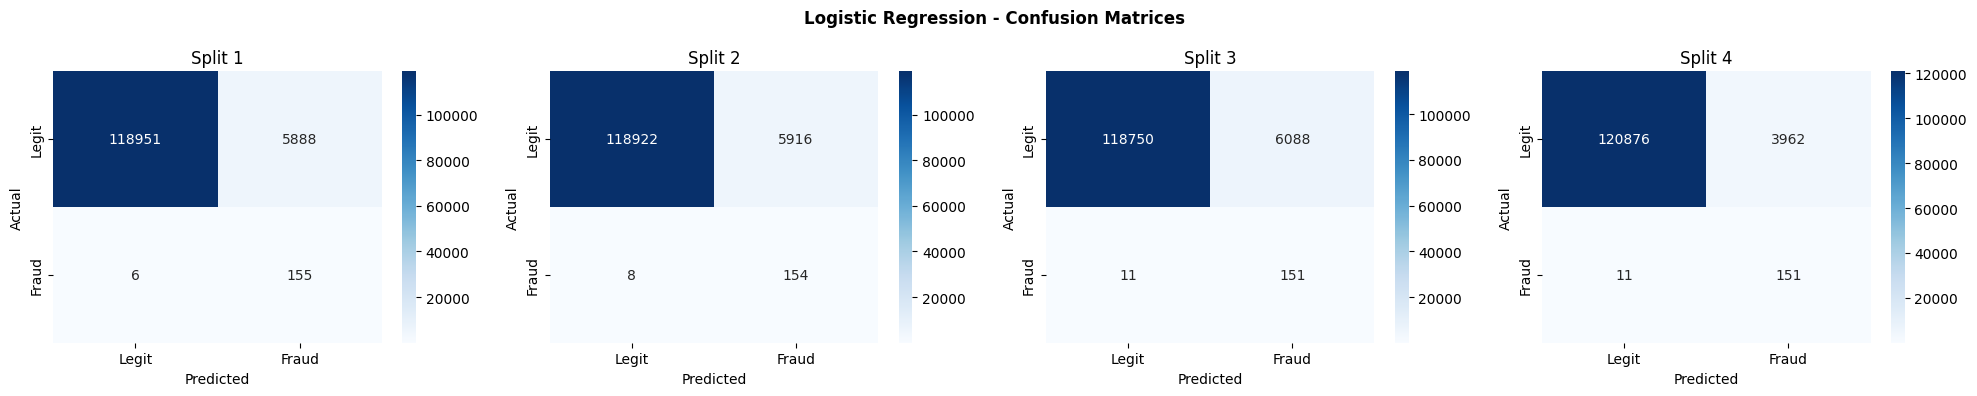

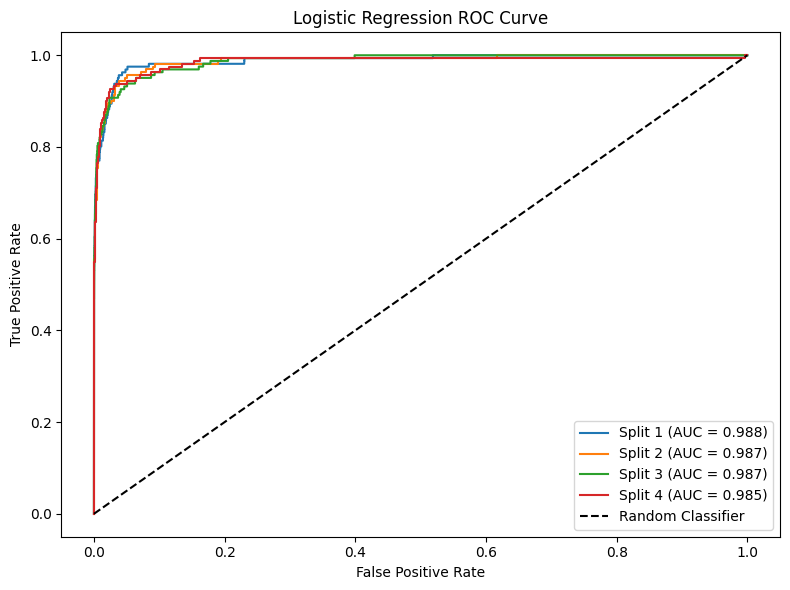

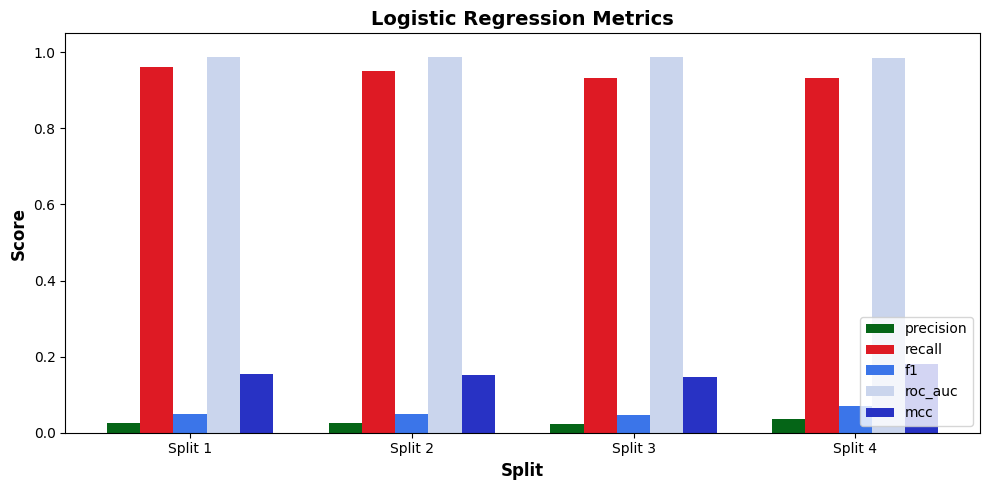

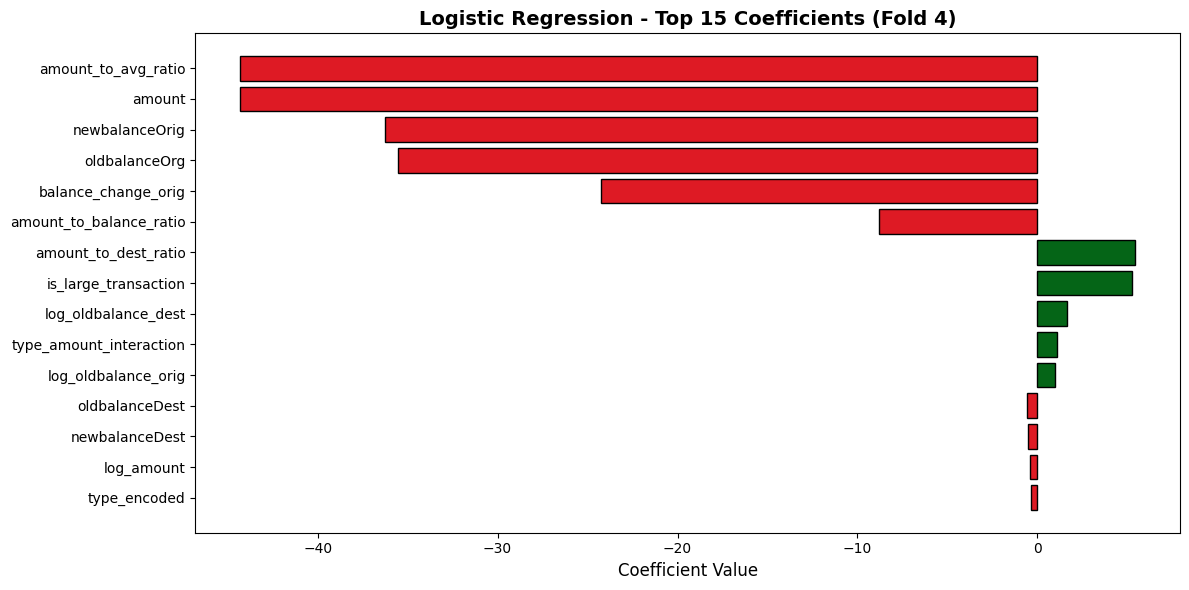

In [151]:
def _lr_predict(train_idx, test_idx):
    """Predict using Logistic Regression for a given fold"""
    X_train, y_train, X_test, y_test = scale_split_only(X, Y, train_idx, test_idx)
    model = _build_lr()
    model.fit(X_train, y_train)
    return model.predict(X_test)

def _lr_predict_proba(train_idx, test_idx):
    """Predict probabilities using Logistic Regression for a given fold"""
    X_train, y_train, X_test, y_test = scale_split_only(X, Y, train_idx, test_idx)
    model = _build_lr()
    model.fit(X_train, y_train)
    return model.predict_proba(X_test)[:, 1]

confusion_matrices(splits, X, Y, _lr_predict,"Logistic Regression", "d1_lr_confusion_matrices.png")
plot_roc_curve(splits, X, Y, _lr_predict_proba,"Logistic Regression", "d1_lr_roc_curves.png")
plot_metrics_bar(lr_results_ds1_df, splits, "Logistic Regression","d1_lr_metrics_by_fold.png")
plot_feature_coefficients(lr_last_model.coef_[0], feature_names,"Logistic Regression", f"Fold {len(splits)}","14_lr_feature_coefficients.png")

### Random Forest Classifier

In [152]:
#training random forest model
rf_results = []
rf_last_model = None
rf_fold_predictions = {}

for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
    X_train, y_train, X_test, y_test = scale_split_only(X, Y, train_idx, test_idx)
    model = _build_rf()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["split"] = split_num
    rf_results.append(metrics)
    rf_fold_predictions[split_num] = {"y_pred": y_pred, "y_prob": y_prob}
    rf_last_model = model

rf_results_ds1_df = pd.DataFrame(rf_results)
rf_results_ds1_df.to_csv(os.path.join(RESULTS, "rf_results.csv"), index=False)
print_summary_table(rf_results_ds1_df, "Random Forest")


 Random Forest Summary Across All Folds
  Metric             Mean        Std
  --------------------------------
  precision        0.8762     0.0367
  recall           0.9954     0.0059
  f1               0.9317     0.0199
  mcc              0.9336     0.0187
  roc_auc          0.9999     0.0001


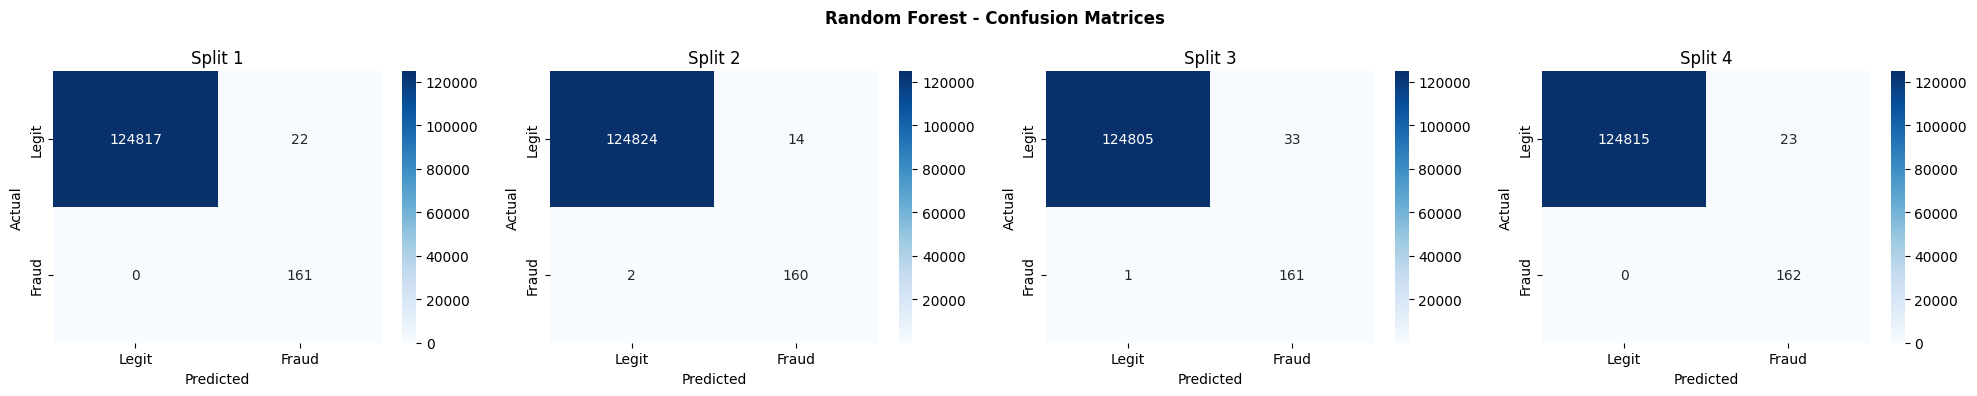

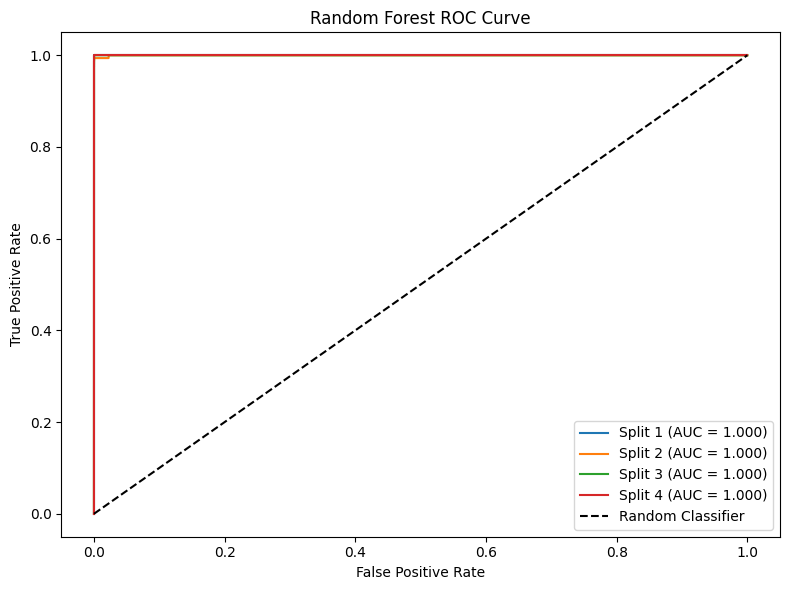

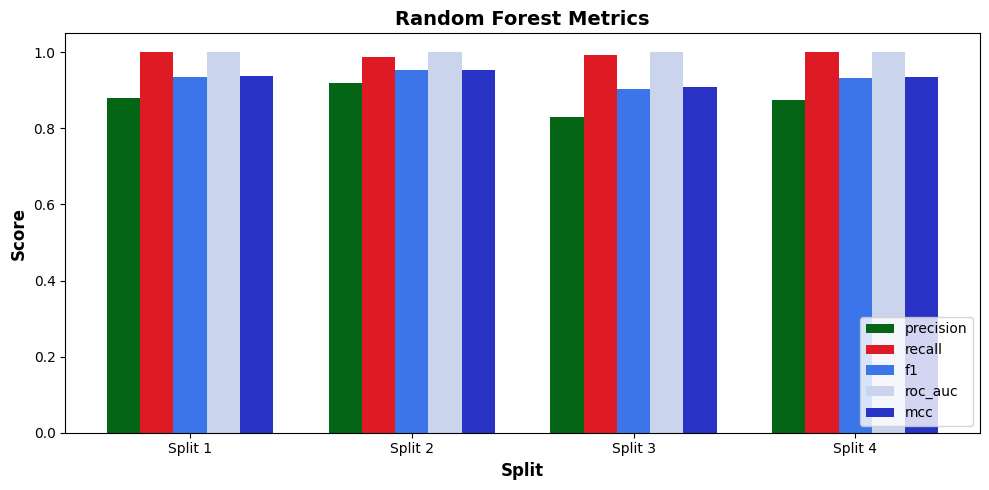

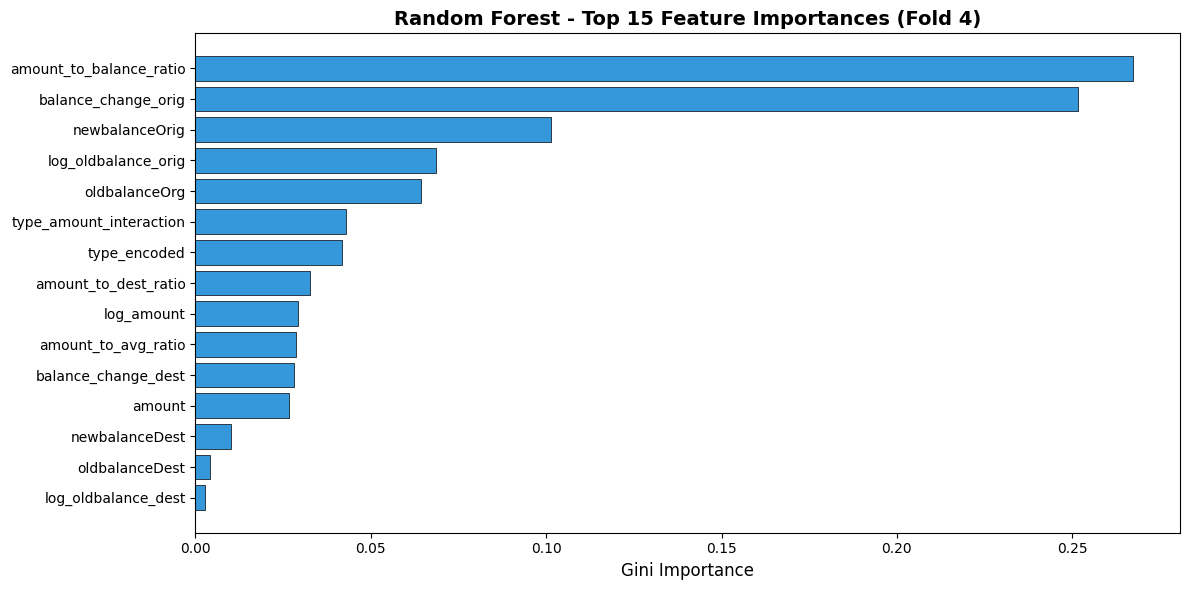

In [153]:
confusion_matrices(splits, X, Y,_make_cached_predictor(rf_fold_predictions, "y_pred", len(splits)),"Random Forest", "d1_rf_confusion_matrices.png")
plot_roc_curve(splits, X, Y,_make_cached_predictor(rf_fold_predictions, "y_prob", len(splits)),"Random Forest", "d1_rf_roc_curves.png")
plot_metrics_bar(rf_results_ds1_df, splits, "Random Forest", "d1_rf_metrics_by_fold.png")
plot_feature_importances(rf_last_model.feature_importances_, feature_names,"Random Forest", f"Fold {len(splits)}","d1_rf_feature_importances.png")

### Feed-Forward Neural Network

In [154]:
input_dim = X.shape[1]
nn_results = []
nn_fold_predictions = {}
all_epoch_losses = {}

for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
    X_train, y_train, X_test, y_test = scale_split_only(X, Y, train_idx, test_idx)
    model, epoch_losses = _train_nn(X_train, y_train, input_dim)
    _, y_prob = _predict(model, X_test, threshold = 0.5)
    thr = best_threshold_f1(y_test.values, y_prob)
    y_pred = (y_prob >= thr).astype(int)
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["threshold"] = thr
    nn_results.append(metrics)
    nn_fold_predictions[split_num] = {"y_pred": y_pred, "y_prob": y_prob}
    all_epoch_losses[split_num] = epoch_losses

nn_results_ds1_df = pd.DataFrame(nn_results)
nn_results_ds1_df.to_csv(os.path.join(RESULTS, "nn_results.csv"), index=False)
print_summary_table(nn_results_ds1_df, "Feed Forward Neural Network")

Epoch   1/50  |  Loss: 0.605318
Epoch  10/50  |  Loss: 0.251864
Epoch  20/50  |  Loss: 0.213198
Epoch  30/50  |  Loss: 0.184489
Epoch  40/50  |  Loss: 0.183960
Epoch  50/50  |  Loss: 0.179383
Epoch   1/50  |  Loss: 0.626284
Epoch  10/50  |  Loss: 0.226623
Epoch  20/50  |  Loss: 0.205803
Epoch  30/50  |  Loss: 0.215308
Epoch  40/50  |  Loss: 0.180305
Epoch  50/50  |  Loss: 0.232979
Epoch   1/50  |  Loss: 0.602871
Epoch  10/50  |  Loss: 0.248283
Epoch  20/50  |  Loss: 0.202208
Epoch  30/50  |  Loss: 0.173999
Epoch  40/50  |  Loss: 0.170825
Epoch  50/50  |  Loss: 0.173966
Epoch   1/50  |  Loss: 0.594074
Epoch  10/50  |  Loss: 0.218046
Epoch  20/50  |  Loss: 0.183167
Epoch  30/50  |  Loss: 0.186470
Epoch  40/50  |  Loss: 0.182804
Epoch  50/50  |  Loss: 0.153294

 Feed Forward Neural Network Summary Across All Folds
  Metric             Mean        Std
  --------------------------------
  precision        0.8779     0.0413
  recall           0.7141     0.0162
  f1               0.7873     0

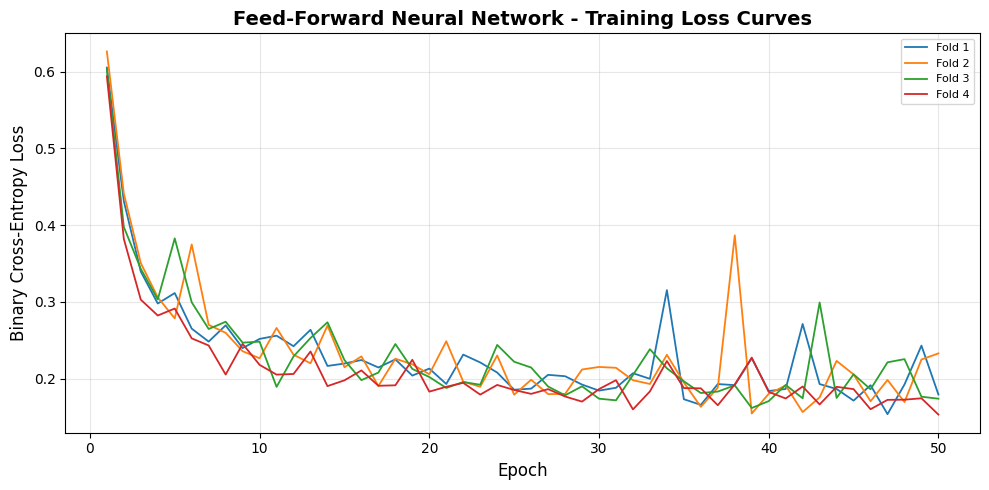

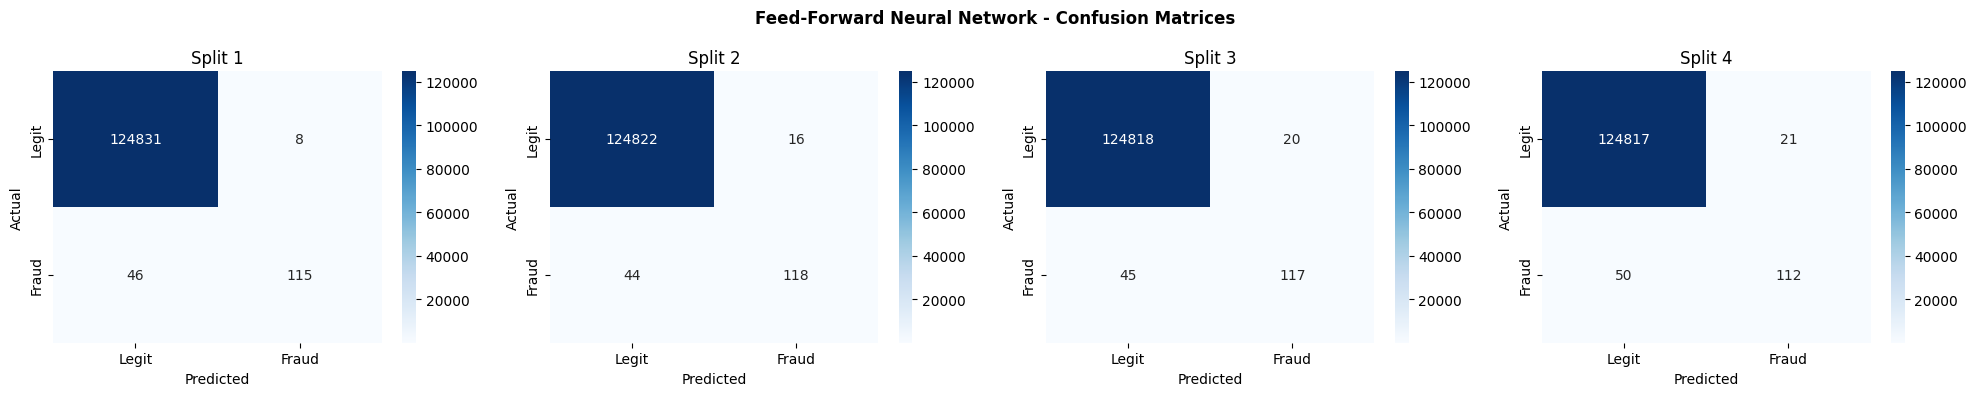

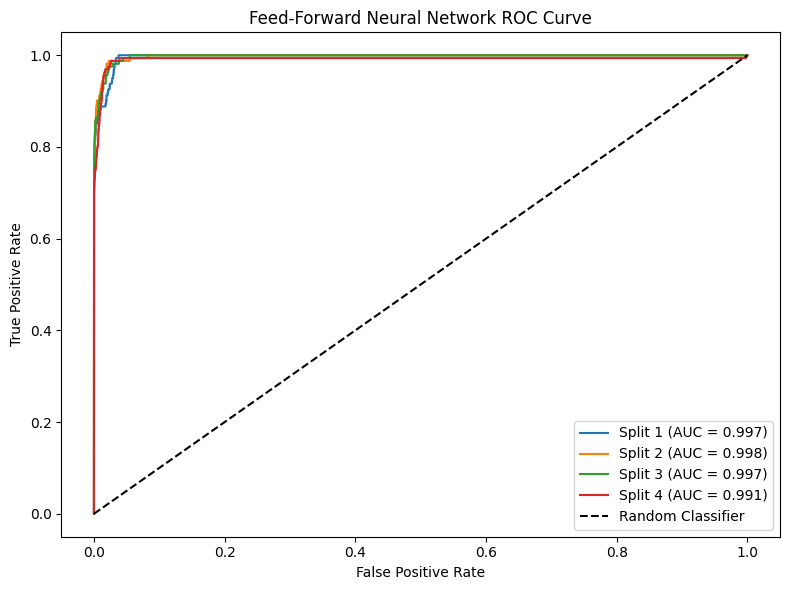

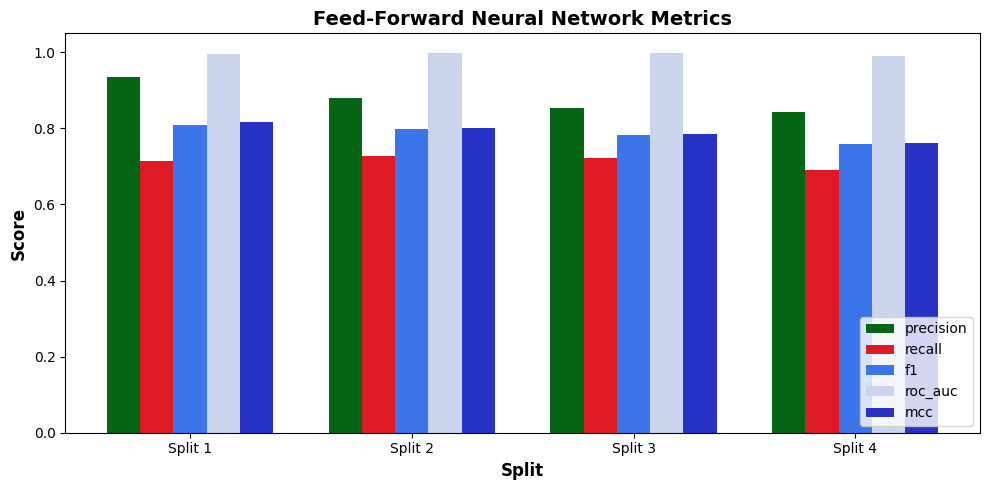


Feed-Forward Neural Network complete.


In [155]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap("tab10")
for split_num in sorted(all_epoch_losses.keys()):
    losses = all_epoch_losses[split_num]
    ax.plot(range(1, len(losses) + 1), losses,
            label=f"Fold {split_num}", color=cmap((split_num - 1) % 10), linewidth=1.3)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)
ax.set_title("Feed-Forward Neural Network - Training Loss Curves",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig(fig, "d1_nn_training_loss.png")

confusion_matrices(splits, X, Y,_make_cached_predictor(nn_fold_predictions, "y_pred", len(splits)),"Feed-Forward Neural Network", "d1_nn_confusion_matrices.png")
plot_roc_curve(splits, X, Y,_make_cached_predictor(nn_fold_predictions, "y_prob", len(splits)),"Feed-Forward Neural Network", "d1_nn_roc_curves.png")
plot_metrics_bar(nn_results_ds1_df, splits, "Feed-Forward Neural Network","d1_nn_metrics_by_fold.png")
print("\nFeed-Forward Neural Network complete.")

In [156]:
summary_frames = {"Logistic Regression": lr_results_ds1_df,"Random Forest": rf_results_ds1_df,"Feed-Forward NN": nn_results_ds1_df}
metric_cols = ["precision", "recall", "f1", "mcc", "roc_auc"]
summary = pd.DataFrame({
    name: frame[metric_cols].mean()
    for name, frame in summary_frames.items()
}).T

print("Mean metrics across all 4 folds:")
print(summary.round(4))
summary.to_csv(os.path.join(RESULTS, "summary_mean_metrics.csv"))

Mean metrics across all 4 folds:
                     precision  recall      f1     mcc  roc_auc
Logistic Regression     0.0280  0.9444  0.0543  0.1579   0.9868
Random Forest           0.8762  0.9954  0.9317  0.9336   0.9999
Feed-Forward NN         0.8779  0.7141  0.7873  0.7914   0.9957


#Dataset 2

##Preprocessing

In [157]:
dset2_df = Dataset2.sample(n=min(SAMPLE_SIZE, len(Dataset2)), random_state=42) #Edit for final run, dset2_df = Dataset2

dset2_df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
437378,437378,0.420468,-0.070194,-0.569266,0.191673,-0.009607,0.426903,-0.356728,0.096143,0.077806,...,0.134969,0.070433,0.047770,-0.851622,0.102876,-0.375436,0.820807,0.665983,8633.18,1
504222,504222,-0.238944,0.250929,-0.374408,0.152938,-0.105008,-0.039028,-0.293004,0.133771,-0.591631,...,0.192405,0.289441,-0.255187,-0.817462,0.308284,1.582688,0.574425,0.478489,12299.55,1
4794,4794,-0.117796,-0.147961,2.130455,-0.325762,0.325616,0.271351,0.772625,-0.244342,1.240012,...,-0.271739,-0.404654,-0.121235,0.857659,0.541920,0.756534,-0.238177,-0.403038,5215.87,0
388411,388411,-0.855315,0.137014,-0.628116,0.613733,-0.643573,-0.664283,-0.880040,0.466586,-1.045508,...,0.405505,0.167560,0.446262,-0.205976,0.492582,0.658619,1.609128,-0.025592,19282.98,1
424512,424512,0.257686,0.035247,-0.203112,0.506745,-0.242235,-0.192608,-0.289297,0.044488,-0.396122,...,0.162191,0.165912,-0.181999,0.331451,1.043095,0.029799,0.643273,0.736723,19114.27,1


In [158]:
RESULTS = "Dataset2 results"
os.makedirs(RESULTS, exist_ok=True)

###Dataset Cleaning

In [159]:
# drop ID column to prevent memorization
if "id" in dset2_df.columns:
    dset2_df = dset2_df.drop(columns=["id"])

# check for missing values
missing = dset2_df.isnull().sum()
total_missing = missing.sum()
print(f"\nMissing values: {total_missing}")
if total_missing > 0:
    print(missing[missing > 0])

# check for duplicate rows to prevent information leakage
duplicates = dset2_df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")
if duplicates > 0:
    dset2_df = dset2_df.drop_duplicates().reset_index(drop=True)
    print(f"  -> New shape: {dset2_df.shape[0]:,} rows")


Missing values: 0
Duplicate rows: 1
  -> New shape: 499,999 rows


###Dataset Analysis

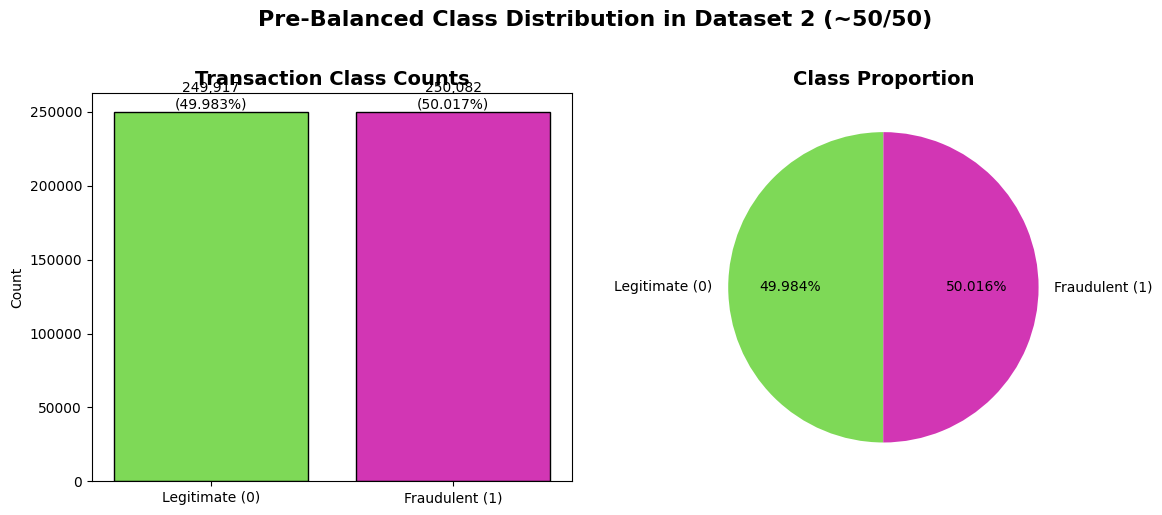

In [160]:
class_counts = dset2_df["Class"].value_counts().sort_index()
class_pct = dset2_df["Class"].value_counts(normalize=True).sort_index() * 100
colors = ["#7ed957", "#d236b4"]
labels = ["Legitimate (0)", "Fraudulent (1)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(labels, class_counts.values, color=colors, edgecolor="black")
axes[0].set_title("Transaction Class Counts", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
for i, (cnt, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    axes[0].text(i, cnt + cnt * 0.01, f"{cnt:,}\n({pct:.3f}%)", ha="center", fontsize=10)

axes[1].pie(class_counts.values, labels=labels, colors=colors, autopct="%1.3f%%", startangle=90)
axes[1].set_title("Class Proportion", fontsize=14, fontweight="bold")

fig.suptitle("Pre-Balanced Class Distribution in Dataset 2 (~50/50)",fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "Dataset2_class_distribution.png")

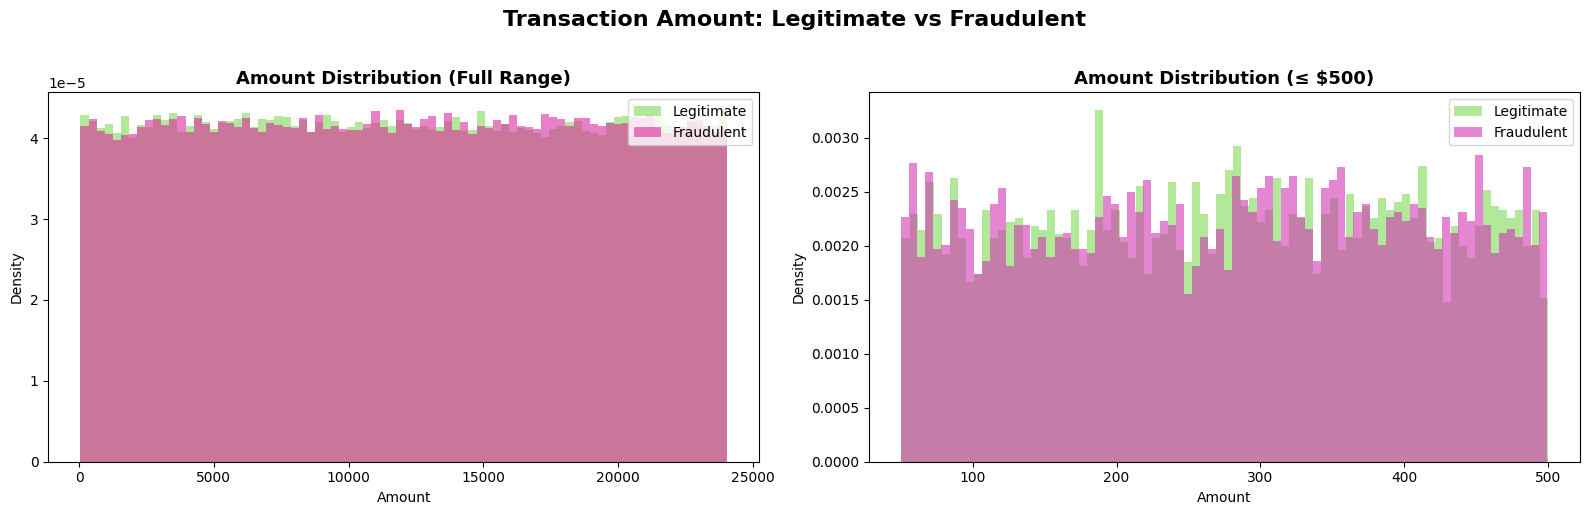

In [161]:
legit = dset2_df[dset2_df["Class"] == 0]["Amount"]
fraud = dset2_df[dset2_df["Class"] == 1]["Amount"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(legit, bins=80, alpha=0.6, color="#7ed957", label="Legitimate", density=True)
axes[0].hist(fraud, bins=80, alpha=0.6, color="#db2a9d", label="Fraudulent", density=True)
axes[0].set_title("Amount Distribution (Full Range)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Amount"); axes[0].set_ylabel("Density"); axes[0].legend()

#given that the majority of transactions seem to appear below $500 this range is used for cleaerer visualization
axes[1].hist(legit[legit <= 500], bins=80, alpha=0.6, color="#7ed957", label="Legitimate", density=True)
axes[1].hist(fraud[fraud <= 500], bins=80, alpha=0.6, color="#d236b4", label="Fraudulent", density=True)
axes[1].set_title("Amount Distribution (≤ $500)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Amount"); axes[1].set_ylabel("Density"); axes[1].legend()

fig.suptitle("Transaction Amount: Legitimate vs Fraudulent", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "Dataset2_amount_distribution.png")


  Features most negatively correlated with Class(fraud):
    V14       r = -0.8059
    V12       r = -0.7685
    V3        r = -0.6823
    V10       r = -0.6737
    V9        r = -0.5855

  Features most positively correlated with Class(fraud):
    V27       r = +0.2134
    V19       r = +0.2440
    V2        r = +0.4915
    V11       r = +0.7245
    V4        r = +0.7361


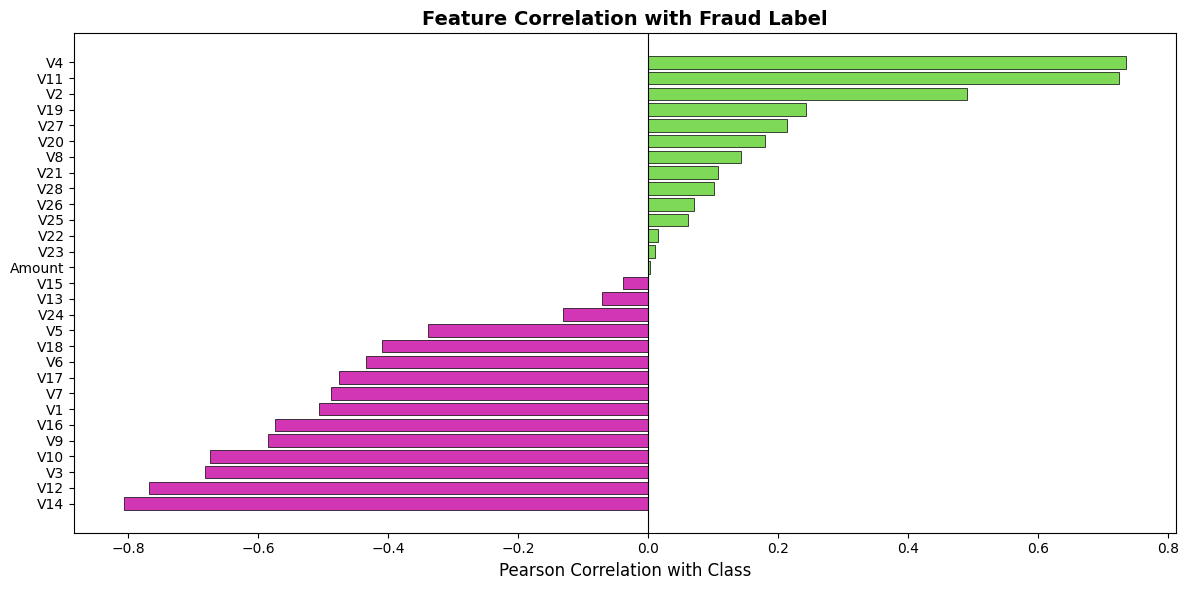

In [162]:
v_cols = [f"V{i}" for i in range(1, 29)]
feature_cols = v_cols + ["Amount"]
corr_with_class = (
    dset2_df[feature_cols + ["Class"]].corr()["Class"].drop("Class").sort_values()
)

print("  Features most negatively correlated with Class(fraud):")
for feat, corr in corr_with_class.head(5).items():
    print(f"    {feat:<8}  r = {corr:+.4f}")

print("\n  Features most positively correlated with Class(fraud):")
for feat, corr in corr_with_class.tail(5).items():
    print(f"    {feat:<8}  r = {corr:+.4f}")

#the green bar increases a prediction of fraud while the red increses the prediction of a legitimate transaction
fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ["#d236b4" if v < 0 else "#7ed957" for v in corr_with_class.values]
ax.barh(corr_with_class.index, corr_with_class.values, color=bar_colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Pearson Correlation with Class", fontsize=12)
ax.set_title("Feature Correlation with Fraud Label", fontsize=14, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)
fig.tight_layout()
save_fig(fig, "Dataset2_feature_correlation_with_class.png")


###Preparing Data for Training Models

In [163]:
X = dset2_df.drop(columns=["Class"])
y = dset2_df["Class"]

In [164]:
#dataset already balanced hence no SMOTE
def scale_split(X, y, train_idx, test_idx):
    feature_names = X.columns.tolist()
    X_train_raw = X.iloc[train_idx]
    X_test_raw = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_raw),
        columns=feature_names, index=X_train_raw.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_raw),
        columns=feature_names, index=X_test_raw.index,
    )

    return X_train_scaled, y_train, X_test_scaled, y_test, scaler

splits = create_kfold_splits(X, y)
for i, (train_idx, test_idx) in enumerate(splits, start=1):
    train_fraud = y.iloc[train_idx].sum()
    test_fraud = y.iloc[test_idx].sum()
    test_pct = test_fraud / len(test_idx) * 100

###Evaluation Helpers

In [165]:
def plot_confusion_matrices(splits, X_features, y, train_and_predict_fn, model_name, filename):
    fig, axes = plt.subplots(1, len(splits), figsize=(4 * len(splits), 4))
    if len(splits) == 1:
        axes = [axes]

    for i, (train_idx, test_idx) in enumerate(splits, start=1):
        y_pred = train_and_predict_fn(train_idx, test_idx)
        y_test = y.loc[test_idx]
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i - 1], xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"], cbar=False)
        axes[i - 1].set_title(f"Fold {i}", fontsize=11, fontweight="bold")
        axes[i - 1].set_ylabel("Actual"); axes[i - 1].set_xlabel("Predicted")

    fig.suptitle(f"{model_name} - Confusion Matrices", fontsize=16, fontweight="bold", y=1.02)
    fig.tight_layout()
    save_fig(fig, filename)

def plot_roc_curves(splits, X_features, y, train_and_predict_proba_fn, model_name, filename):
    fig, ax = plt.subplots(figsize=(8, 6))

    for i, (train_idx, test_idx) in enumerate(splits, start=1):
        y_prob = train_and_predict_proba_fn(train_idx, test_idx)
        y_test = y.iloc[test_idx]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"Fold {i} (AUC={auc_val:.4f})", alpha=0.7)

    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Classifier")
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(f"{model_name} ROC Curves", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    save_fig(fig, filename)

def plot_metrics_bars(results_dset2_df, splits, model_name, filename):
    fig, ax = plt.subplots(figsize=(14, 5))
    metrics_to_plot = ["precision", "recall", "f1", "mcc", "roc_auc"]
    x = np.arange(len(splits))
    width = 0.15
    colors_metrics = ["#3498db", "#7ed957", "#d236b4", "#9b59b6", "#f39c12"]

    for i, metric in enumerate(metrics_to_plot):
        ax.bar(x + i * width, results_dset2_df[metric].values, width,
               label=metric.upper().replace("_", "-"), color=colors_metrics[i])

    ax.set_xlabel("Fold", fontsize=12); ax.set_ylabel("Score", fontsize=12)
    ax.set_title(f"{model_name} - Metrics by Fold", fontsize=14, fontweight="bold")
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels([f"F{i+1}" for i in range(len(splits))])
    ax.legend(loc="lower right"); ax.set_ylim(0, 1.05)
    fig.tight_layout()
    save_fig(fig, filename)

def plot_feature_coefficients(coefs, feature_names, model_name, fold_label, filename, top_n=15):
    fig, ax = plt.subplots(figsize=(12, 6))
    sorted_idx = np.argsort(np.abs(coefs))[::-1]
    ax.barh(range(top_n), coefs[sorted_idx[:top_n]], color=["#d236b4" if c < 0 else "#7ed957"
                   for c in coefs[sorted_idx[:top_n]]],edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]])
    ax.set_xlabel("Coefficient Value", fontsize=12)
    ax.set_title(f"{model_name} - Top {top_n} Feature Coefficients ({fold_label})", fontsize=14, fontweight="bold")
    ax.invert_yaxis()
    fig.tight_layout()
    save_fig(fig, filename)



##Logistic Regression

In [166]:
feature_names = X.columns.tolist()
lr_results = []
lr_last_model = None

for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
    X_train, y_train, X_test, y_test, _ = scale_split(X, y, train_idx, test_idx)
    model = _build_lr()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["split"] = split_num
    lr_results.append(metrics)
    lr_last_model = model

lr_dset2_df = pd.DataFrame(lr_results)
lr_dset2_df.to_csv(os.path.join(RESULTS, "lr_results.csv"), index=False)
print_summary_table(lr_dset2_df, "Logistic Regression")


 Logistic Regression Summary Across All Folds
  Metric             Mean        Std
  --------------------------------
  precision        0.9777     0.0007
  recall           0.9516     0.0009
  f1               0.9645     0.0006
  mcc              0.9302     0.0011
  roc_auc          0.9936     0.0003


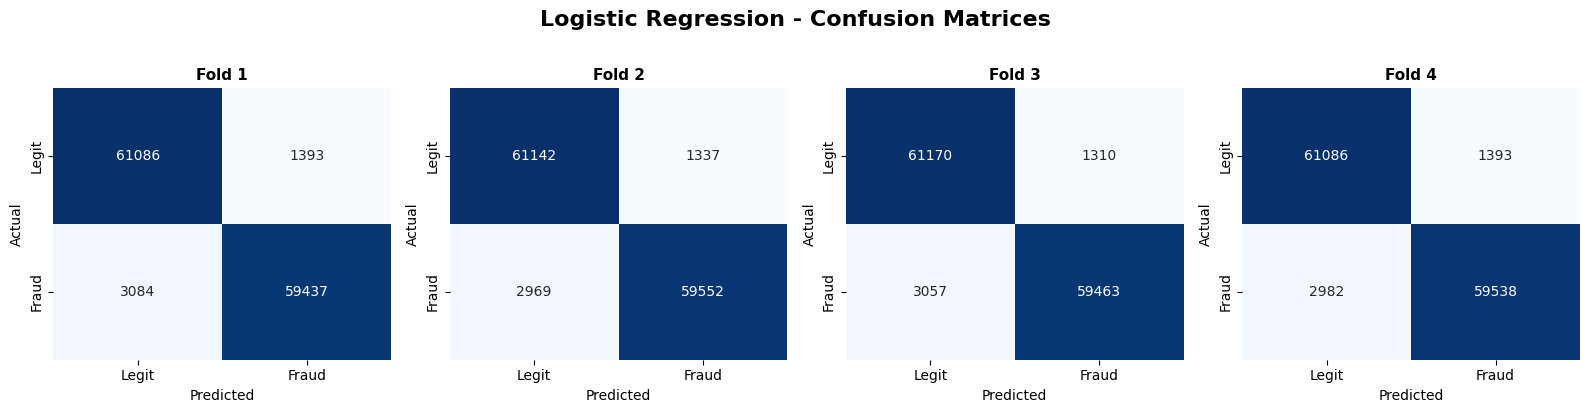

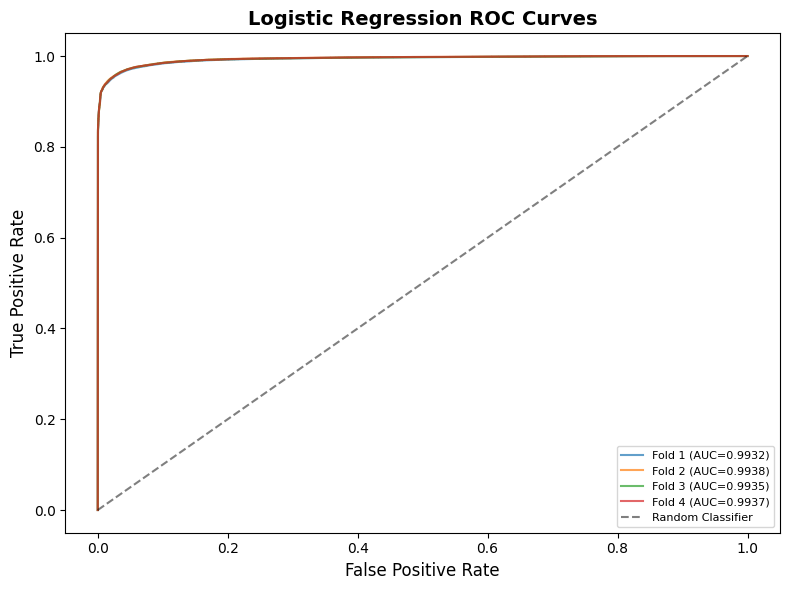

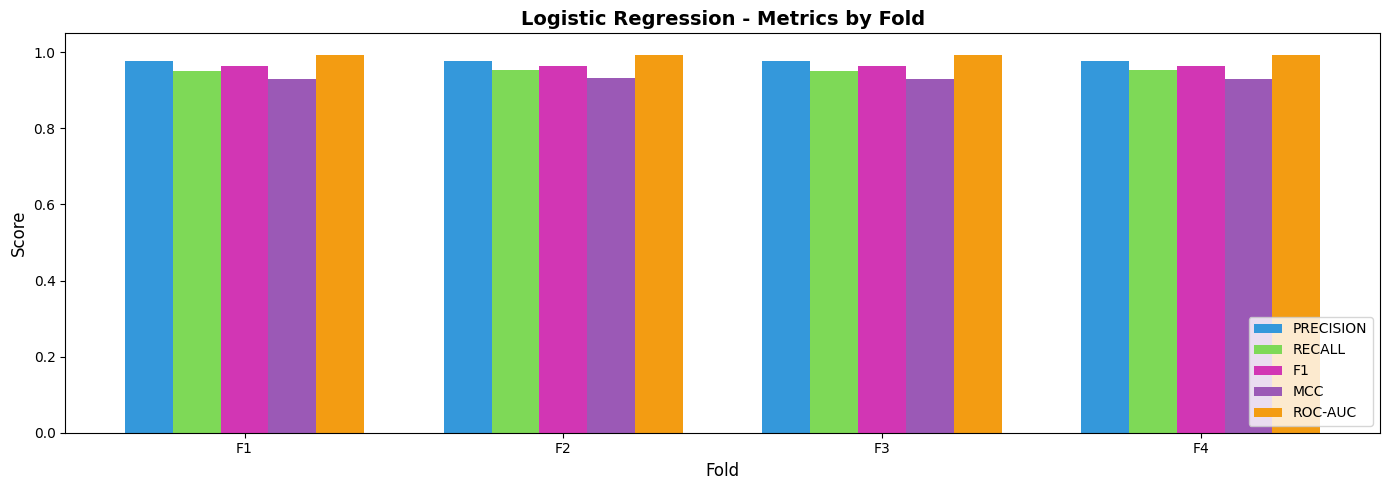

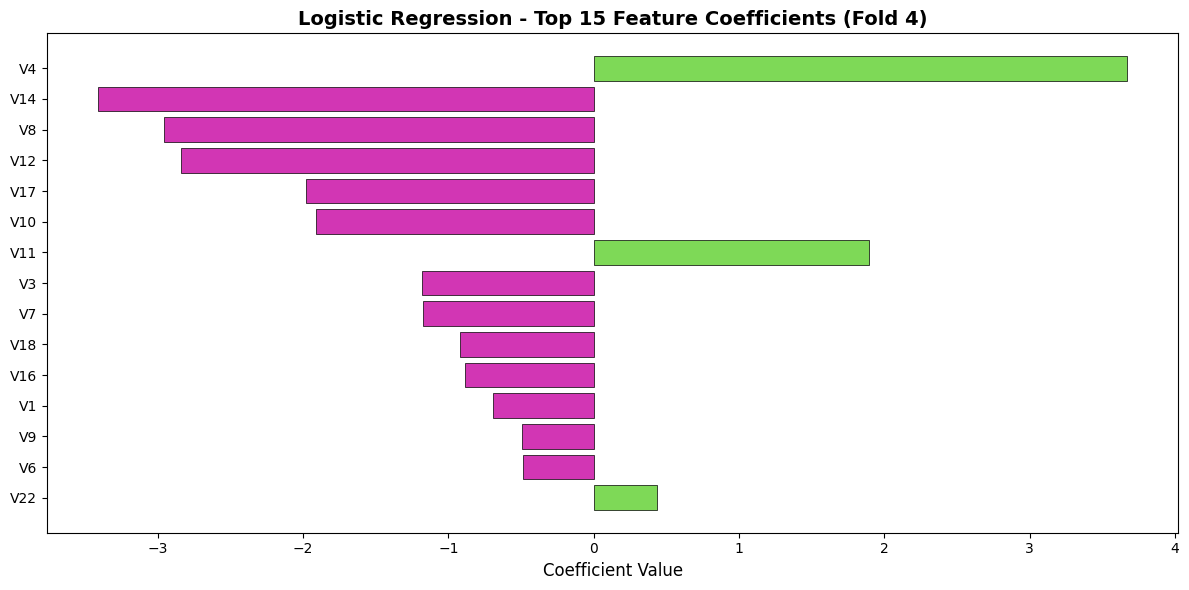

In [167]:
def _lr_predict(train_idx, test_idx):
    X_tr, y_tr, X_te, _, _ = scale_split(X, y, train_idx, test_idx)
    m = _build_lr(); m.fit(X_tr, y_tr)
    return m.predict(X_te)

def _lr_predict_proba(train_idx, test_idx):
    X_tr, y_tr, X_te, _, _ = scale_split(X, y, train_idx, test_idx)
    m = _build_lr(); m.fit(X_tr, y_tr)
    return m.predict_proba(X_te)[:, 1]

plot_confusion_matrices(splits, X, y, _lr_predict,"Logistic Regression", "11_lr_confusion_matrices.png")
plot_roc_curves(splits, X, y, _lr_predict_proba,"Logistic Regression", "12_lr_roc_curves.png")
plot_metrics_bars(lr_dset2_df, splits, "Logistic Regression","13_lr_metrics_by_fold.png")
plot_feature_coefficients(lr_last_model.coef_[0], feature_names,"Logistic Regression", f"Fold {len(splits)}","14_lr_feature_coefficients.png")

##Random forest

In [168]:
rf_results = []
rf_last_model = None
rf_fold_predictions = {}

for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
    X_train, y_train, X_test, y_test, _ = scale_split(X, y, train_idx, test_idx)
    model = _build_rf()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["split"] = split_num
    rf_results.append(metrics)
    rf_fold_predictions[split_num] = {"y_pred": y_pred, "y_prob": y_prob}
    rf_last_model = model

rf_dset2_df = pd.DataFrame(rf_results)
rf_dset2_df.to_csv(os.path.join(RESULTS, "rf_results.csv"), index=False)
print_summary_table(rf_dset2_df, "Random Forest")



 Random Forest Summary Across All Folds
  Metric             Mean        Std
  --------------------------------
  precision        0.9992     0.0001
  recall           0.9998     0.0001
  f1               0.9995     0.0001
  mcc              0.9990     0.0002
  roc_auc          1.0000     0.0000


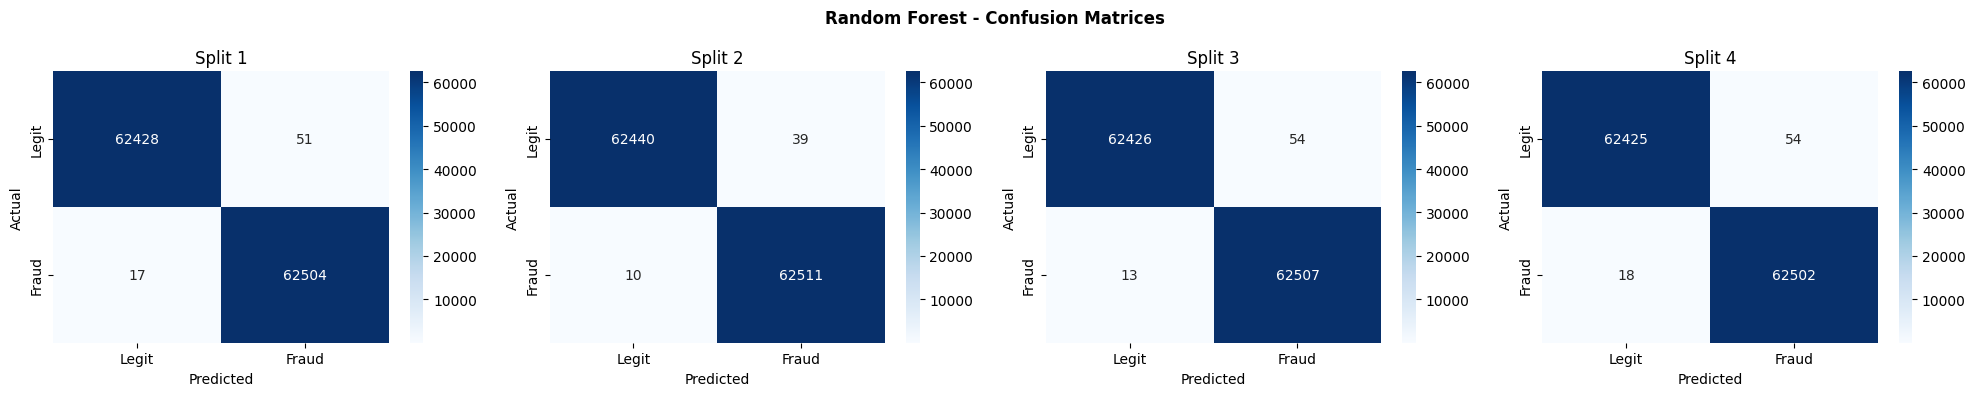

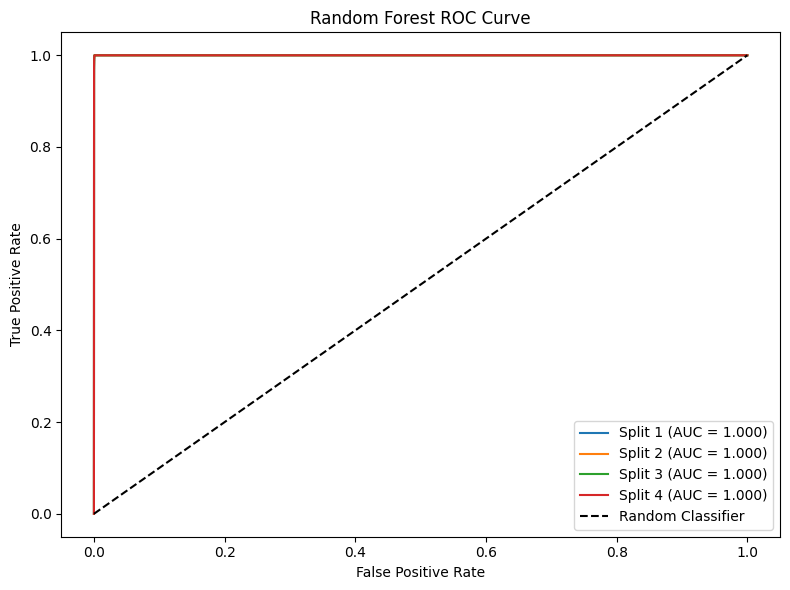

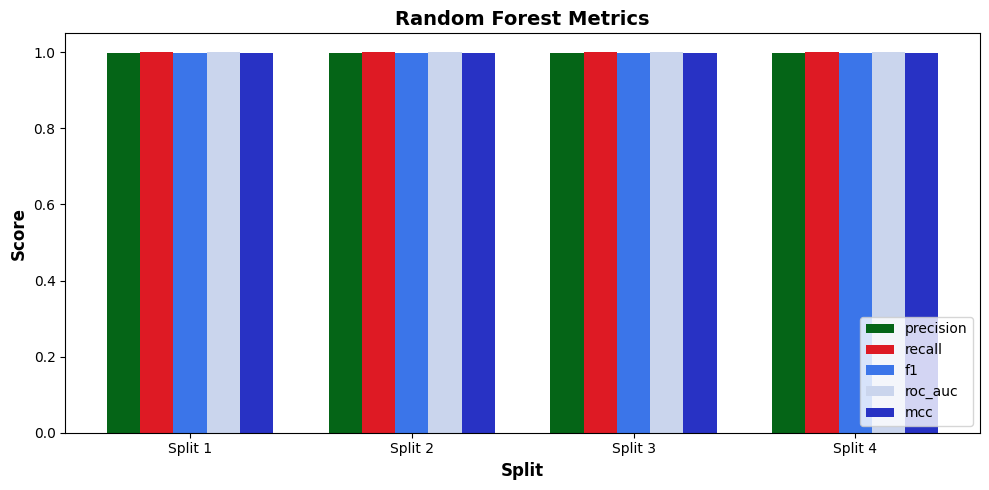

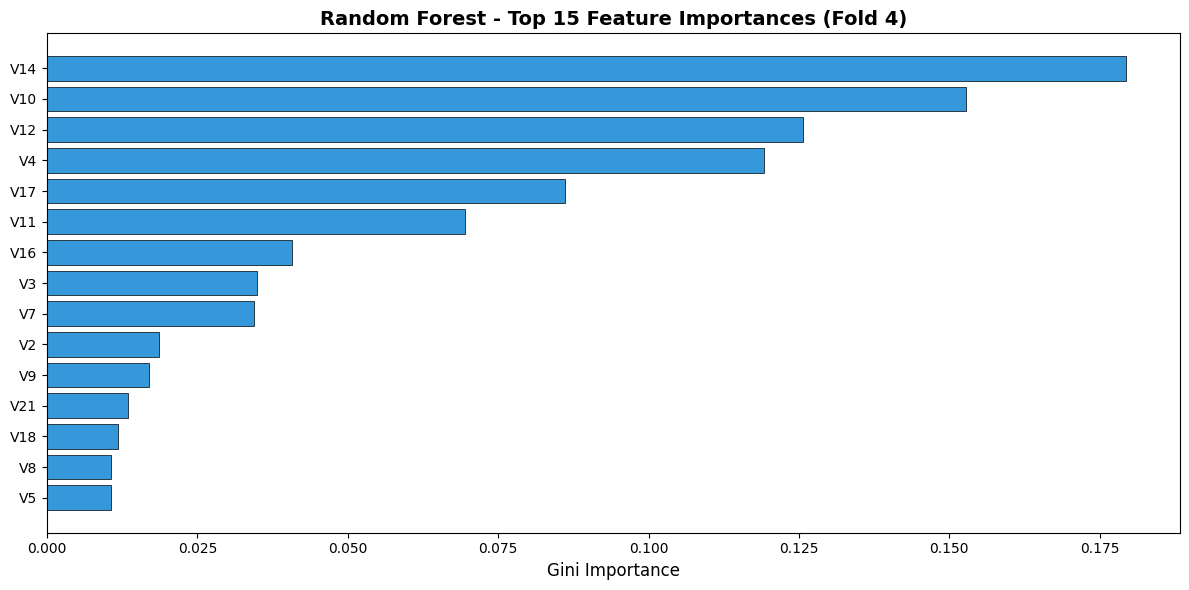

In [169]:
confusion_matrices(splits, X, y,_make_cached_predictor(rf_fold_predictions, "y_pred", len(splits)),"Random Forest", "15_rf_confusion_matrices.png")
plot_roc_curve(splits, X, y,_make_cached_predictor(rf_fold_predictions, "y_prob", len(splits)),"Random Forest", "16_rf_roc_curves.png")
plot_metrics_bar(rf_dset2_df, splits, "Random Forest", "17_rf_metrics_by_fold.png")
plot_feature_importances(rf_last_model.feature_importances_, feature_names,"Random Forest", f"Fold {len(splits)}","18_rf_feature_importances.png")

##Feed-Forward Neural Network

In [170]:
input_dim = X.shape[1]
nn_results = []
nn_fold_predictions = {}
all_epoch_losses = {}

for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
    X_train, y_train, X_test, y_test, _ = scale_split(X, y, train_idx, test_idx)
    model, epoch_losses = _train_nn(X_train, y_train, input_dim)
    y_pred, y_prob = _predict(model, X_test)
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["split"] = split_num
    nn_results.append(metrics)
    nn_fold_predictions[split_num] = {"y_pred": y_pred, "y_prob": y_prob}
    all_epoch_losses[split_num] = epoch_losses

nn_dset2_df = pd.DataFrame(nn_results)
nn_dset2_df.to_csv(os.path.join(RESULTS, "nn_results.csv"), index=False)
print_summary_table(nn_dset2_df, "Feed-Forward Neural Network")

Epoch   1/50  |  Loss: 0.079989
Epoch  10/50  |  Loss: 0.017728
Epoch  20/50  |  Loss: 0.015204
Epoch  30/50  |  Loss: 0.015324
Epoch  40/50  |  Loss: 0.015025
Epoch  50/50  |  Loss: 0.014677
Epoch   1/50  |  Loss: 0.081261
Epoch  10/50  |  Loss: 0.017805
Epoch  20/50  |  Loss: 0.015597
Epoch  30/50  |  Loss: 0.014883
Epoch  40/50  |  Loss: 0.015169
Epoch  50/50  |  Loss: 0.014704
Epoch   1/50  |  Loss: 0.080771
Epoch  10/50  |  Loss: 0.017342
Epoch  20/50  |  Loss: 0.015480
Epoch  30/50  |  Loss: 0.015195
Epoch  40/50  |  Loss: 0.014561
Epoch  50/50  |  Loss: 0.014906
Epoch   1/50  |  Loss: 0.079524
Epoch  10/50  |  Loss: 0.018311
Epoch  20/50  |  Loss: 0.015784
Epoch  30/50  |  Loss: 0.014927
Epoch  40/50  |  Loss: 0.014619
Epoch  50/50  |  Loss: 0.014614

 Feed-Forward Neural Network Summary Across All Folds
  Metric             Mean        Std
  --------------------------------
  precision        0.9973     0.0005
  recall           0.9999     0.0001
  f1               0.9986     0

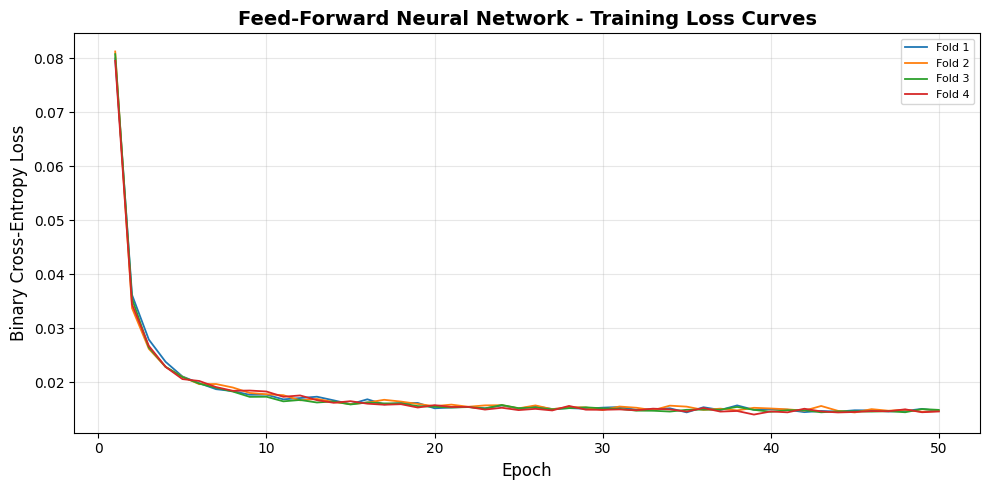

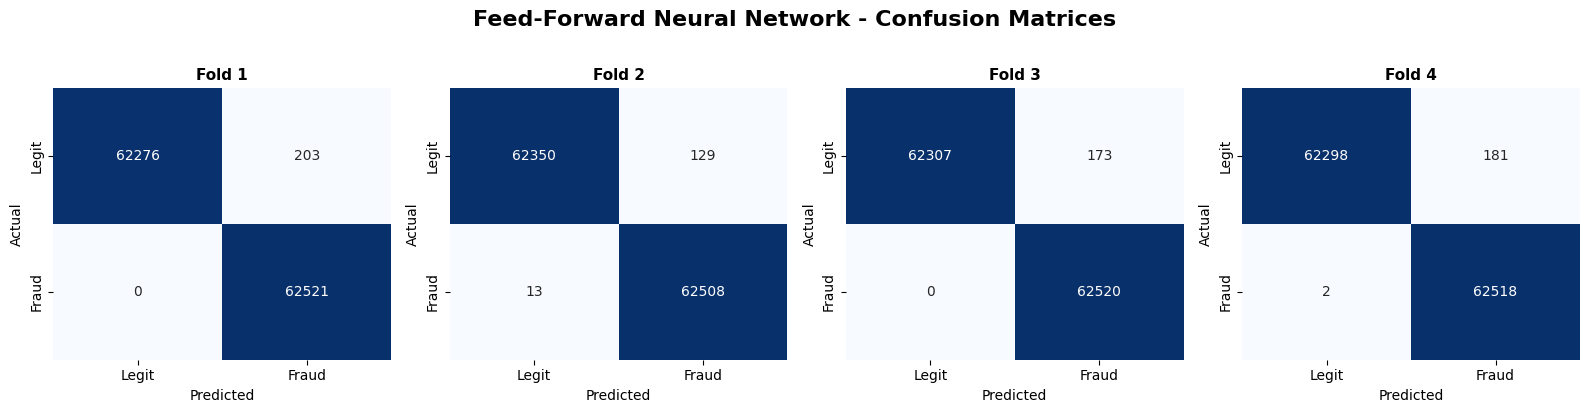

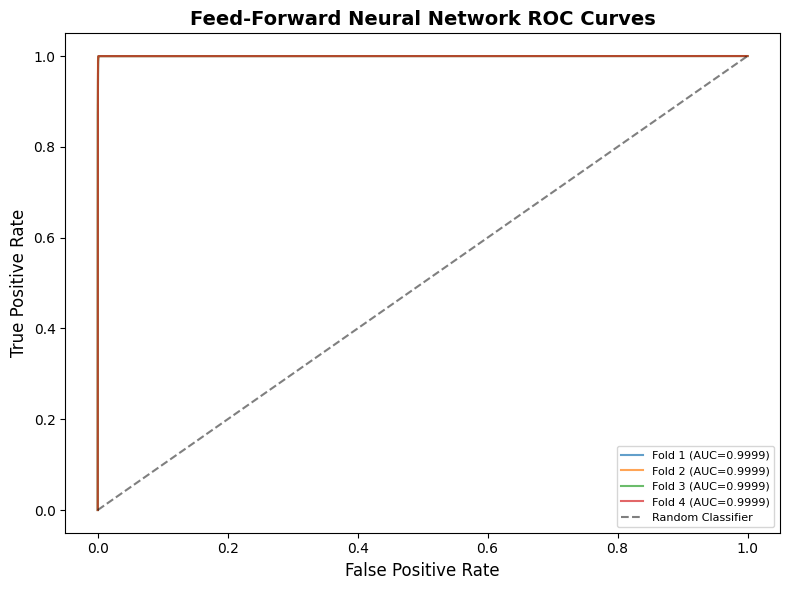

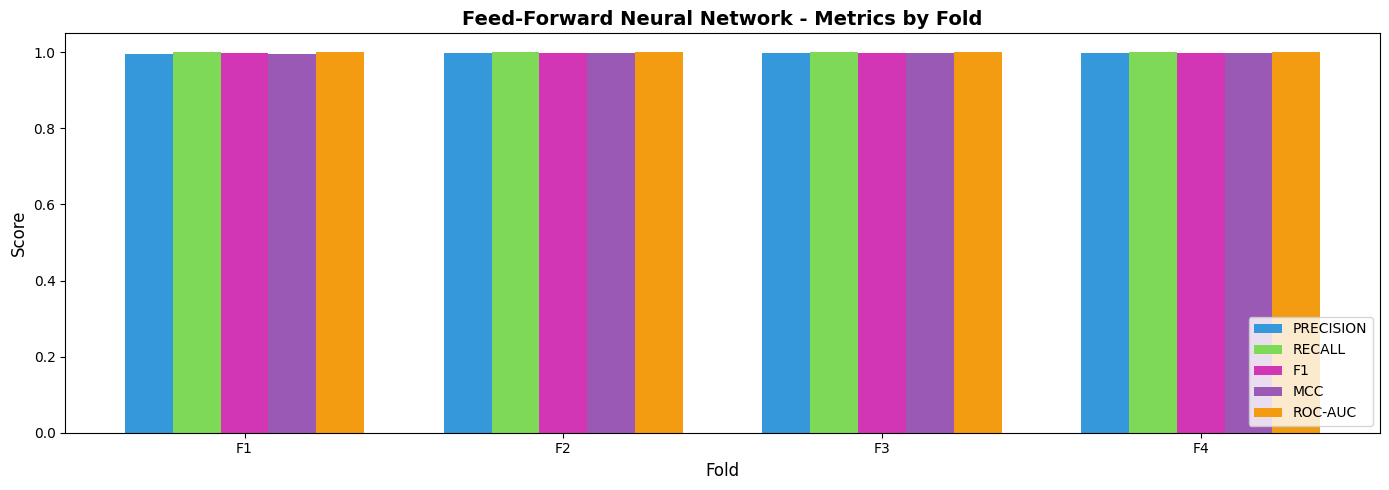


Feed-Forward Neural Network complete.


In [171]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap("tab10")
for split_num in sorted(all_epoch_losses.keys()):
    losses = all_epoch_losses[split_num]
    ax.plot(range(1, len(losses) + 1), losses,
            label=f"Fold {split_num}", color=cmap((split_num - 1) % 10), linewidth=1.3)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)
ax.set_title("Feed-Forward Neural Network - Training Loss Curves",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig(fig, "19_nn_training_loss.png")

plot_confusion_matrices(splits, X, y,_make_cached_predictor(nn_fold_predictions, "y_pred", len(splits)),"Feed-Forward Neural Network", "20_nn_confusion_matrices.png")
plot_roc_curves(splits, X, y,_make_cached_predictor(nn_fold_predictions, "y_prob", len(splits)),"Feed-Forward Neural Network", "21_nn_roc_curves.png")
plot_metrics_bars(nn_dset2_df, splits, "Feed-Forward Neural Network","22_nn_metrics_by_fold.png")
print("\nFeed-Forward Neural Network complete.")


In [172]:
summary_frames = {"Logistic Regression": lr_dset2_df,"Random Forest": rf_dset2_df,"Feed-Forward NN": nn_dset2_df}
metric_cols = ["precision", "recall", "f1", "mcc", "roc_auc"]
summary = pd.DataFrame({
    name: frame[metric_cols].mean()
    for name, frame in summary_frames.items()
}).T

print("Mean metrics across all 4 folds:")
print(summary.round(4))
summary.to_csv(os.path.join(RESULTS, "summary_mean_metrics.csv"))

Mean metrics across all 4 folds:
                     precision  recall      f1     mcc  roc_auc
Logistic Regression     0.9777  0.9516  0.9645  0.9302   0.9936
Random Forest           0.9992  0.9998  0.9995  0.9990   1.0000
Feed-Forward NN         0.9973  0.9999  0.9986  0.9972   0.9999


# Dataset 3

### Plan of Action
1. Load Data from kaggle
2. Clean and display information about it
3. Time-based expanding window splits and SMOTE(This is on training data only btw)
4. Logistic Regression - 4 Plots
5. Random Forest
6. FFNN

In [173]:
RD = "sample_data/results/Dataset3"
os.makedirs(RD, exist_ok=True)

## Data Cleaning

In [174]:
Dataset3["Class"] = Dataset3["Class"].astype(int)
missing = Dataset3.isnull().sum()
total_missing = missing.sum()
if total_missing>0:
  Dataset3 = Dataset3.dropna().reset_index(drop=True)
duplicates = Dataset3.duplicated().sum()
if duplicates>0:
  Dataset3 = Dataset3.drop_duplicates().reset_index(drop=True)


# Data Analysis

## Class Distribution in Bar and Pie Chart

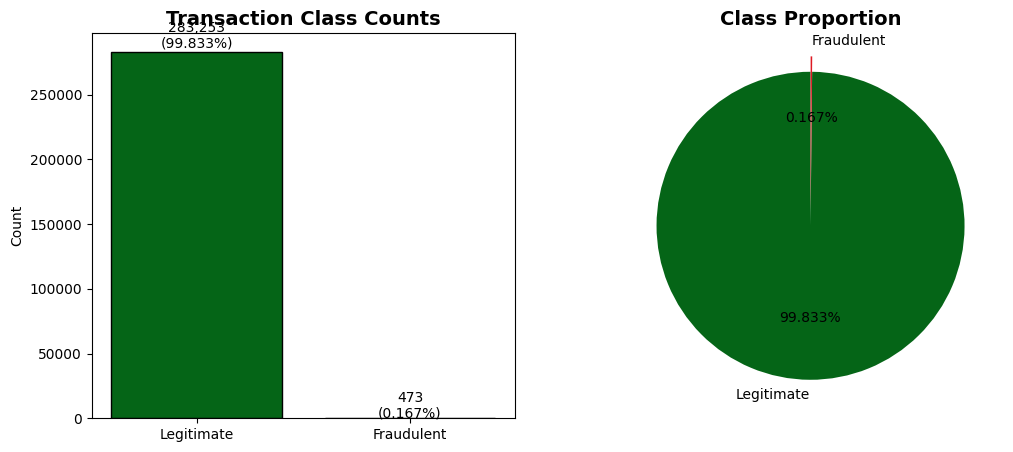

In [175]:
class_counts = Dataset3["Class"].value_counts().sort_index()
class_pct = Dataset3["Class"].value_counts(normalize=True).sort_index() * 100

colors = ["#056517","#de1a24"]
labels = ["Legitimate", "Fraudulent"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(labels, class_counts.values, color=colors, edgecolor="black")
axes[0].set_title("Transaction Class Counts", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
for i in range(len(labels)):
    count = class_counts.values[i]
    pct   = class_pct.values[i]
    y_position = count + count * 0.01
    label_text = f"{count:,}\n({pct:.3f}%)"
    axes[0].text(i, y_position, label_text, ha="center", fontsize=10)

axes[1].pie(class_counts.values,labels=labels,colors=colors,autopct="%1.3f%%",startangle=90,explode=(0, 0.1),)
axes[1].set_title("Class Proportion", fontsize=14, fontweight = "bold")
save_fig(fig, "Dataset_Class_Distribution")

# All Transactions
These two graphs split up all transactions over time and all fraudulent transactions over the same length of time.

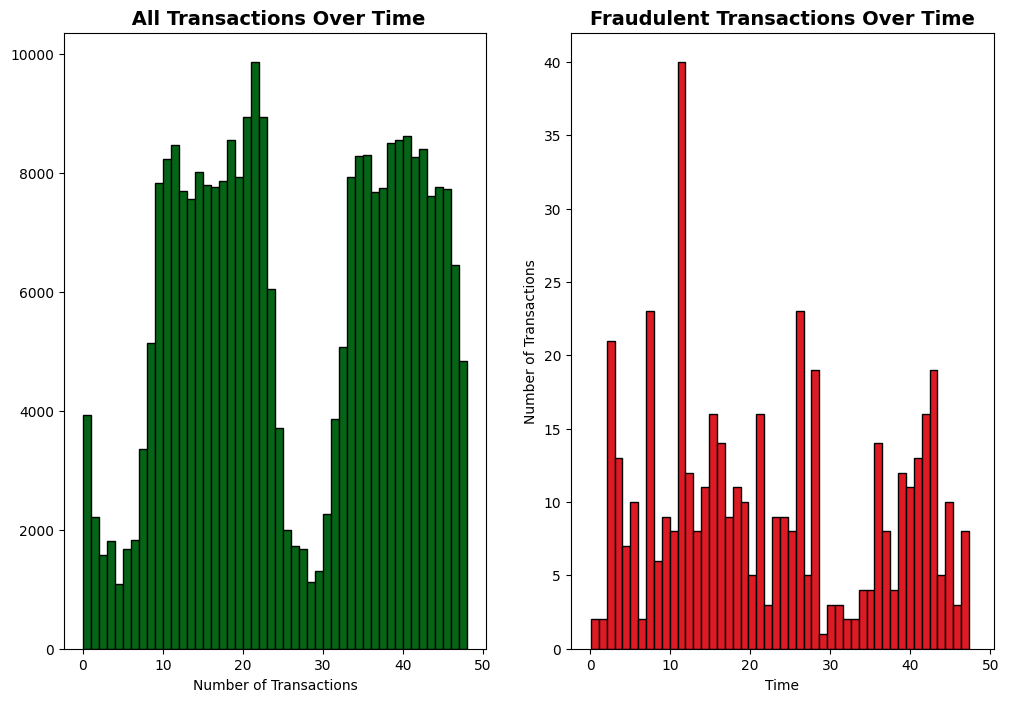

In [176]:
Dataset3["Hour"] = Dataset3["Time"]/3600
total_hours = Dataset3["Hour"].max()
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex = True) # Sharex
axes[0].hist(Dataset3["Hour"], bins = 48, color = "#056517", edgecolor = "black")
axes[0].set_title(" All Transactions Over Time", fontsize = 14, fontweight = "bold")
axes[0].set_xlabel("Number of Transactions")

fraud_hours = Dataset3[Dataset3["Class"] == 1]["Hour"]
axes[1].hist(fraud_hours, bins = 48, color = "#de1a24", edgecolor = "black")
axes[1].set_title("Fraudulent Transactions Over Time", fontsize = 14, fontweight = "bold")
axes[1].set_ylabel("Number of Transactions")
axes[1].set_xlabel("Time")
save_fig(fig, "All_Transactions_Over_Time")


#Feature Correlation Chart
This cell is measuring which features have the strongest linear correlation with the fraud label and plots it out.

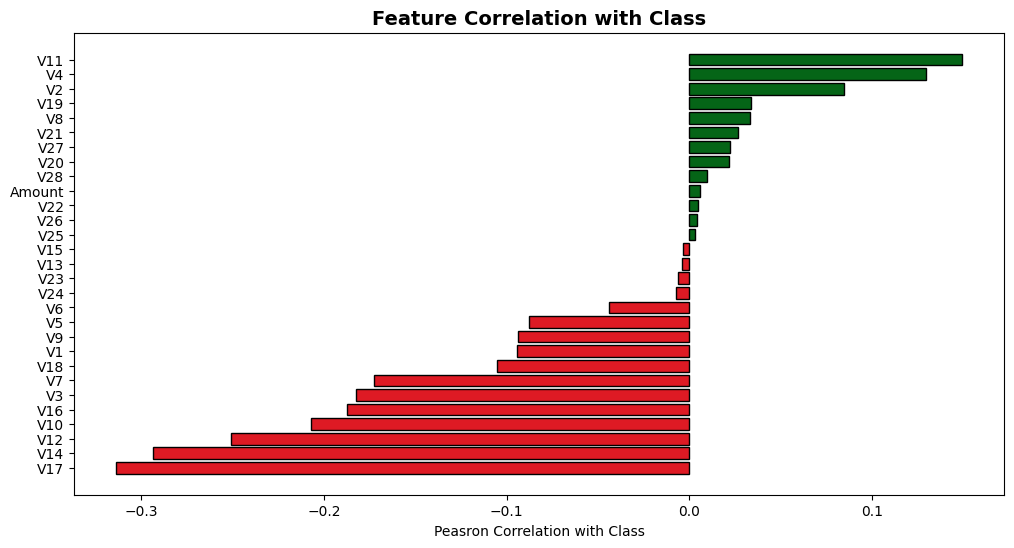

In [177]:
v_cols = [f"V{i}" for i in range (1,29)]
feature_cols = v_cols + ["Amount"]
corr_class = (Dataset3[feature_cols + ["Class"]].corr()["Class"].drop("Class").sort_values())
fig, ax = plt.subplots(figsize = (12,6))
bar_colors = ["#de1a24" if v<0 else "#056517" for v in corr_class.values]
ax.barh(corr_class.index, corr_class.values, color = bar_colors, edgecolor = "black")
ax.set_xlabel("Peasron Correlation with Class")
ax.set_title("Feature Correlation with Class", fontsize = 14, fontweight = "bold")
save_fig(fig, "Feature_Correlation_Chart")

#Preprocessing and Time Splits

In [178]:
Dataset3.drop(columns = ["Hour"], inplace=True, errors ="ignore")#inplace
X = Dataset3.drop(columns = ["Class"])
y = Dataset3["Class"]

def create_time_splits(X, test_window = 8, train_hours=16):
  hours = X["Time"]/3600
  total_hours = hours.max()
  splits = []
  test_start = train_hours

  while test_start < total_hours:
    test_end = min(test_start +test_window, total_hours+1)
    train_mask = hours<test_start
    test_mask = (hours>=test_start) & (hours<test_end)
    train_idx = X[train_mask].index.tolist()
    test_idx = X[test_mask].index.tolist()
    if len(train_idx)>0 and len(test_idx) >0:
      splits.append((train_mask, test_mask))

    test_start += test_window
  return splits


def scale_resample(Xfeatures, y, train_idx, test_idx):
  feature_names = Xfeatures.columns.tolist()

  X_trainr = Xfeatures.iloc[train_idx]
  X_testr = Xfeatures.iloc[test_idx]
  y_trainr = y.iloc[train_idx]
  y_testr = y.iloc[test_idx]
  scaler = StandardScaler()

  XtrainScaled = pd.DataFrame(scaler.fit_transform(X_trainr), columns= feature_names, index=X_trainr.index)
  XtestScaled = pd.DataFrame(scaler.transform(X_testr), columns = feature_names, index = X_testr.index)

  smote = SMOTE(random_state=42)
  X_train_resampled, y_train_resampled = smote.fit_resample(XtrainScaled, y_trainr)

  return X_train_resampled, y_train_resampled, XtestScaled, y_testr

splits = create_time_splits(X)

Had to redo my functions because there were slightly different than what was required

In [179]:


def jconfusion_matrices(splits, Xfeatures, y, train_predict_fn, model_name, file):
    fig, axes = plt.subplots(1, len(splits), figsize=(5 * len(splits), 4))
    if len(splits) == 1:
        axes = [axes]

    for i, (train_idx, test_idx) in enumerate(splits):
        y_pred = train_predict_fn(train_idx, test_idx)
        y_test = y.loc[test_idx]
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                    xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
        axes[i].set_title(f"Split {i + 1}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")

    fig.suptitle(f"{model_name} - Confusion Matrices", fontweight="bold")
    fig.tight_layout()
    save_fig(fig, file)


def jplot_roc_curve(splits, Xfeatures, y, train_predict_proba_fn, model_name, file):
    fig, ax = plt.subplots(figsize=(8, 6))

    for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
        y_prob = train_predict_proba_fn(train_idx, test_idx)
        y_test = y.loc[test_idx]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"Split {split_num} (AUC = {auc_val:.3f})")

    ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{model_name} ROC Curve")
    ax.legend(loc="lower right")
    fig.tight_layout()
    save_fig(fig, file)

def jscale_resample(X, y, train_idx, test_idx):
    feature_names = X.columns.tolist()
    X_train_raw = X.loc[train_idx]
    X_test_raw = X.loc[test_idx]
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw))
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw))

    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    return X_train_resampled, y_train_resampled, X_test_scaled, y_test



# MODELS

## Logistic Regression

In [180]:
Xfeatures = X.drop(columns = ["Time"])
feature_names = Xfeatures.columns.tolist()
lr_results = []
lm = None
for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
  X_train_resampled, y_train_resampled, XtestScaled, y_testr = jscale_resample(Xfeatures, y, train_idx, test_idx)
  model = _build_lr()
  model.fit(X_train_resampled, y_train_resampled)
  y_pred = model.predict(XtestScaled)
  y_prob = model.predict_proba(XtestScaled)[:,1]
  metrics = compute_metrics(y_testr, y_pred, y_prob)
  lr_results.append(metrics)
lm = model
lr_results = pd.DataFrame(lr_results)

### Visualizations

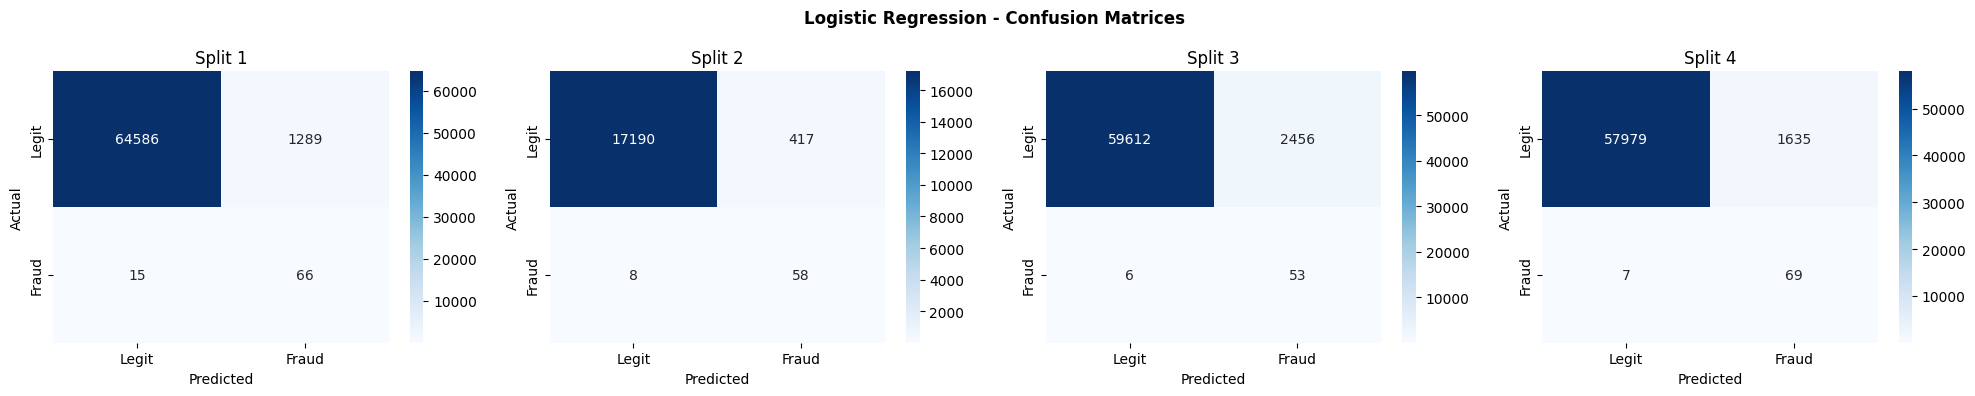

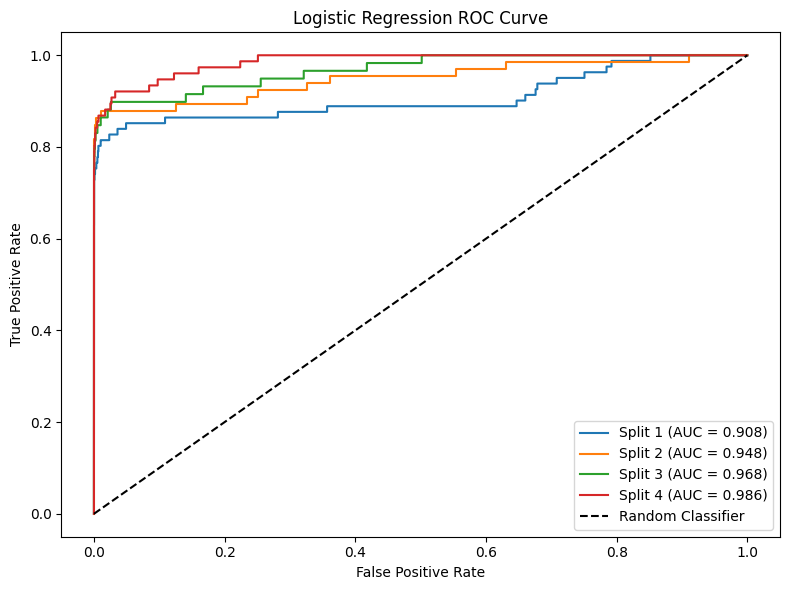

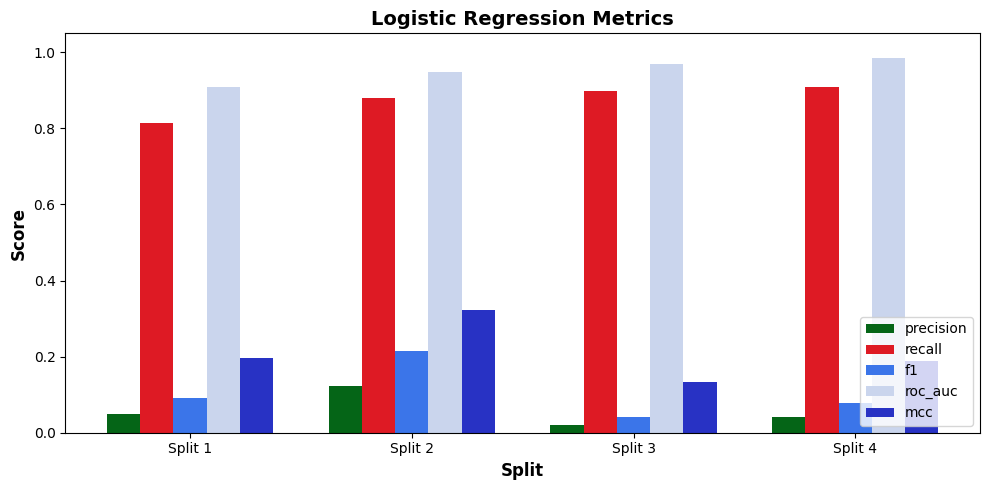

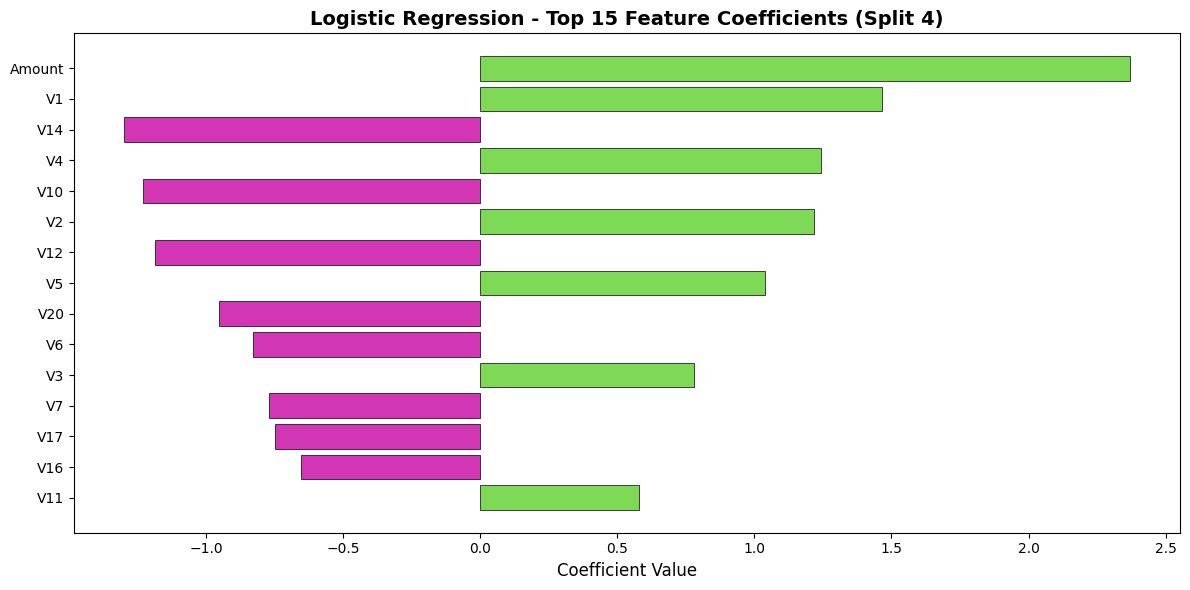

In [181]:
def _lr_train_predict(train_idx, test_idx):
    X_tr, y_tr, X_te, _, = jscale_resample(Xfeatures, y, train_idx, test_idx)
    model = _build_lr()
    model.fit(X_tr, y_tr)
    return model.predict(X_te)

def _lr_train_predict_proba(train_idx, test_idx):
    X_tr, y_tr, X_te, _, = jscale_resample(Xfeatures, y, train_idx, test_idx)
    model = _build_lr()
    model.fit(X_tr, y_tr)
    return model.predict_proba(X_te)[:, 1]

jconfusion_matrices(splits, Xfeatures, y, _lr_train_predict, "Logistic Regression", "Logistic_Regression_Confusion_Matrix")
jplot_roc_curve(splits, Xfeatures, y, _lr_train_predict_proba,"Logistic Regression", "Logistic_Regression_ROC_Curve")
plot_metrics_bar(pd.DataFrame(lr_results), splits,"Logistic Regression", "Logistic_Regression_Metrics")
plot_feature_coefficients(lm.coef_[0], feature_names,"Logistic Regression", f"Split {len(splits)}", "Datadet3_LR_feature_coefficients.png")

# Random Forest

In [182]:
rf_results = []
rf_last_model = None

for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
  X_train_resampled, y_train_resampled, XtestScaled, y_testr = jscale_resample(Xfeatures, y, train_idx, test_idx)
  model = _build_rf()
  model.fit(X_train_resampled, y_train_resampled)
  y_pred = model.predict(XtestScaled)
  y_prob = model.predict_proba(XtestScaled)[:, 1]
  metrics = compute_metrics(y_testr, y_pred, y_prob)
  metrics["split"] = split_num
  rf_results.append(metrics)
  rf_last_model = model

rf_df = pd.DataFrame(rf_results)

### Visualizations

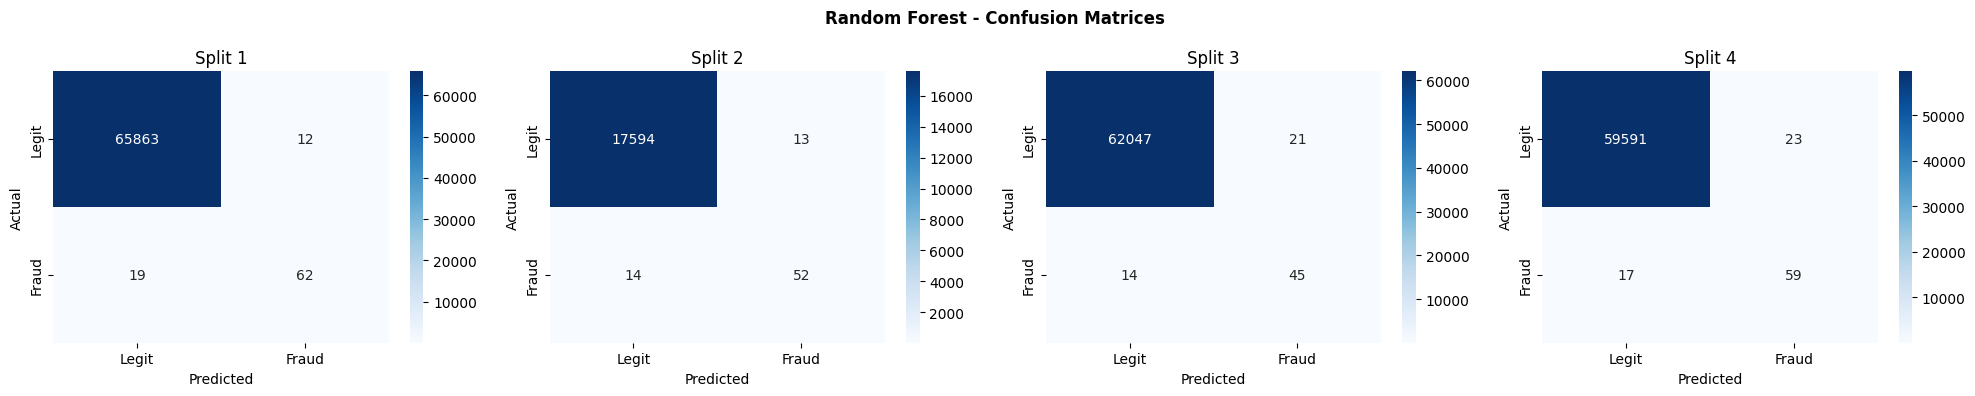

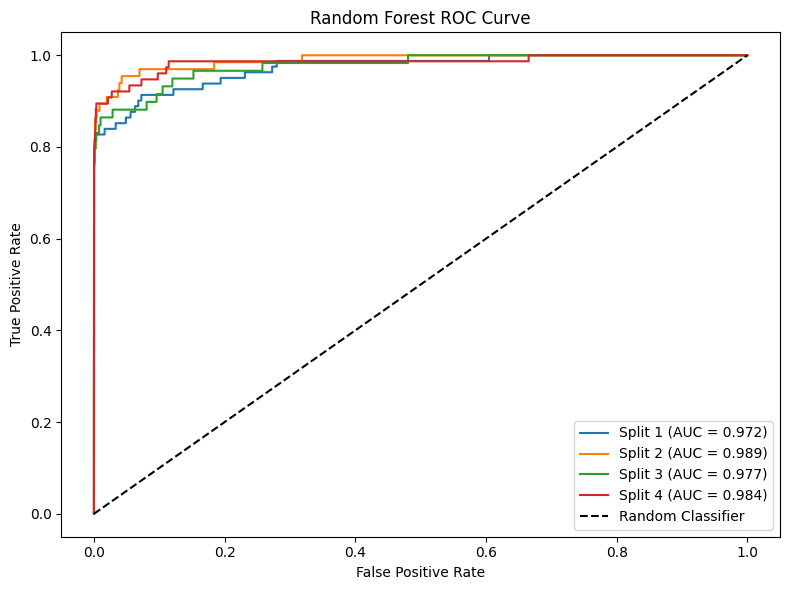

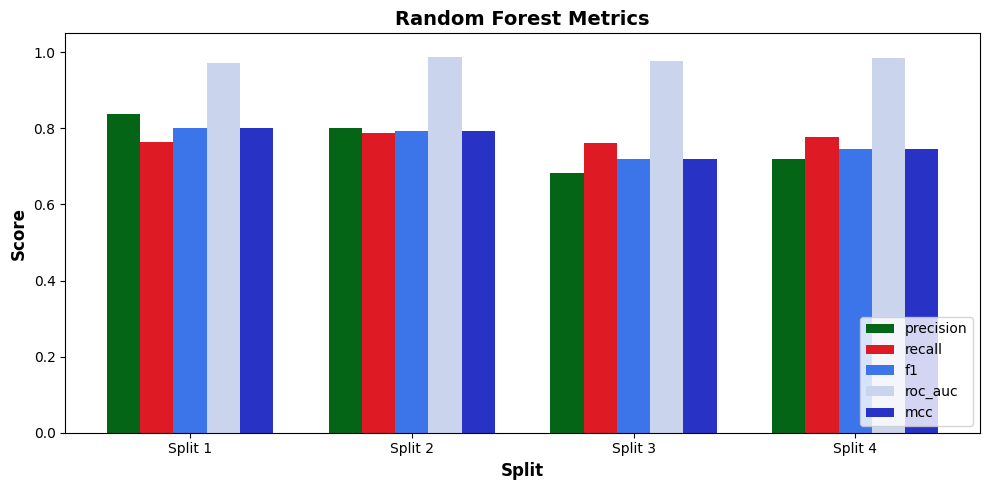

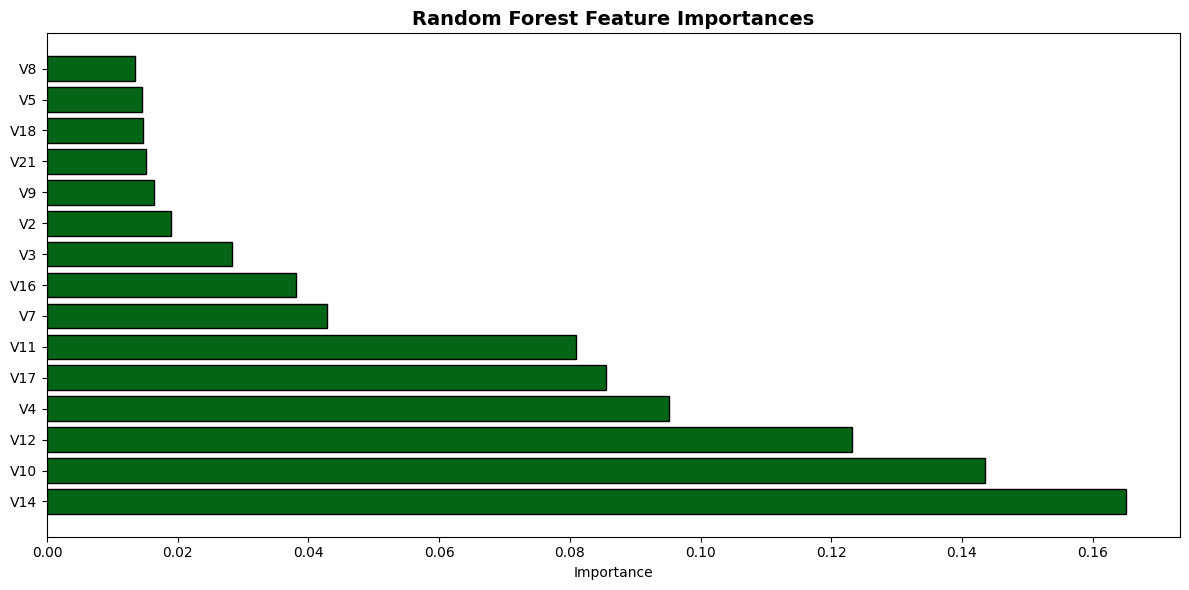

In [183]:
def _rf_train_predict(train_idx, test_idx):
  X_tr, y_tr, X_te, _ = jscale_resample(Xfeatures, y, train_idx, test_idx)
  m = _build_rf()
  m.fit(X_tr, y_tr)
  return m.predict(X_te)

def _rf_train_predict_proba(train_idx, test_idx):
  X_tr, y_tr, X_te, _ = jscale_resample(Xfeatures, y, train_idx, test_idx)
  m = _build_rf()
  m.fit(X_tr, y_tr)
  return m.predict_proba(X_te)[:, 1]

jconfusion_matrices(splits, Xfeatures, y, _rf_train_predict, "Random Forest", "RandomForestConfusionMatrices.png")
jplot_roc_curve(splits, Xfeatures, y, _rf_train_predict_proba, "Random Forest", "RandomForestROC.png")
plot_metrics_bar(rf_df, splits, "Random Forest", "RandomForestMetrics.png")

importances = rf_last_model.feature_importances_
top_n = 15
sorted_idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(top_n), importances[sorted_idx], color=["#de1a24" if i < 0 else "#056517" for i in importances[sorted_idx]], edgecolor="black")
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importances", fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "RandomForestFeatureImportances.png")

## FFNN Training, Evaluations and Visuals

Epoch   1/50  |  Loss: 0.105184
Epoch  10/50  |  Loss: 0.012431
Epoch  20/50  |  Loss: 0.009872
Epoch  30/50  |  Loss: 0.008853
Epoch  40/50  |  Loss: 0.007768
Epoch  50/50  |  Loss: 0.008755
Epoch   1/50  |  Loss: 0.099888
Epoch  10/50  |  Loss: 0.016177
Epoch  20/50  |  Loss: 0.012280
Epoch  30/50  |  Loss: 0.011229
Epoch  40/50  |  Loss: 0.010812
Epoch  50/50  |  Loss: 0.010609
Epoch   1/50  |  Loss: 0.100446
Epoch  10/50  |  Loss: 0.018173
Epoch  20/50  |  Loss: 0.014892
Epoch  30/50  |  Loss: 0.014442
Epoch  40/50  |  Loss: 0.014214
Epoch  50/50  |  Loss: 0.013621
Epoch   1/50  |  Loss: 0.098043
Epoch  10/50  |  Loss: 0.021983
Epoch  20/50  |  Loss: 0.018923
Epoch  30/50  |  Loss: 0.017497
Epoch  40/50  |  Loss: 0.017338
Epoch  50/50  |  Loss: 0.016771


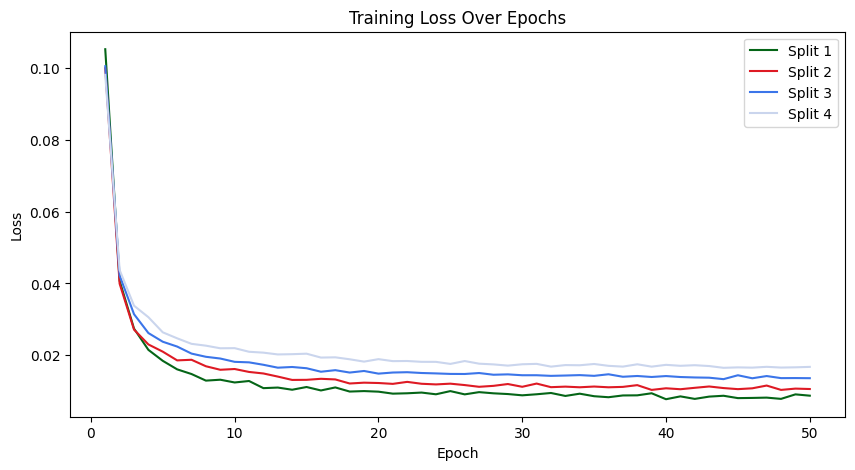

   precision    recall        f1   roc_auc       mcc
0   0.048708  0.814815  0.091922  0.908090  0.196343
1   0.122105  0.878788  0.214418  0.948230  0.322513
2   0.021124  0.898305  0.041277  0.968256  0.134363
3   0.040493  0.907895  0.077528  0.986026  0.188538
   precision    recall        f1   roc_auc       mcc  split
0   0.837838  0.765432  0.800000  0.972402  0.800584      1
1   0.800000  0.787879  0.793893  0.988825  0.793150      2
2   0.681818  0.762712  0.720000  0.977139  0.720852      3
3   0.719512  0.776316  0.746835  0.984445  0.747041      4
   precision    recall        f1   roc_auc       mcc  split
0   0.386364  0.629630  0.478873  0.928624  0.492447      1
1   0.637681  0.666667  0.651852  0.873065  0.650680      2
2   0.455556  0.694915  0.550336  0.927563  0.562149      3
3   0.349112  0.776316  0.481633  0.979974  0.519765      4


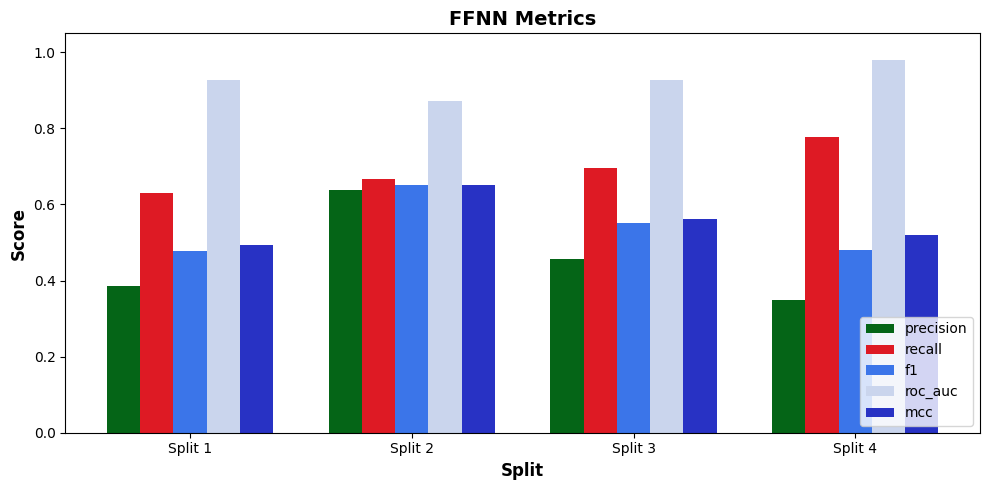

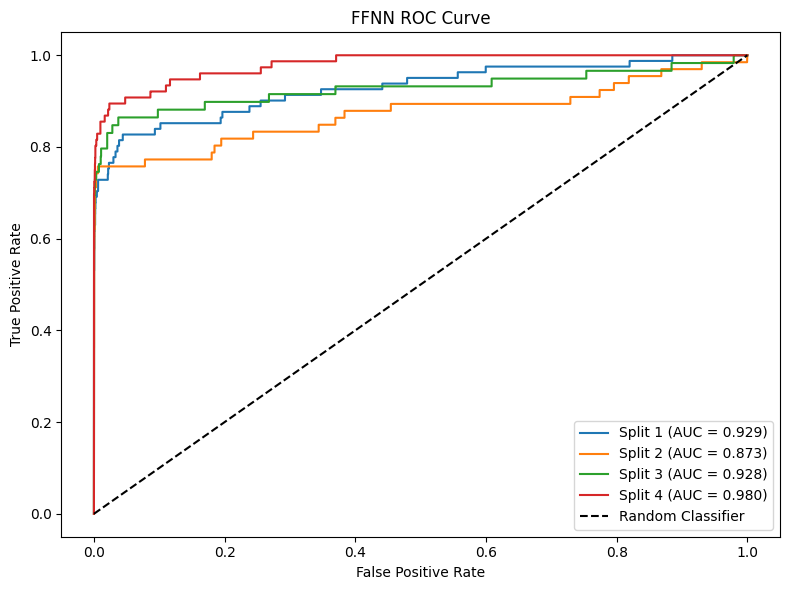

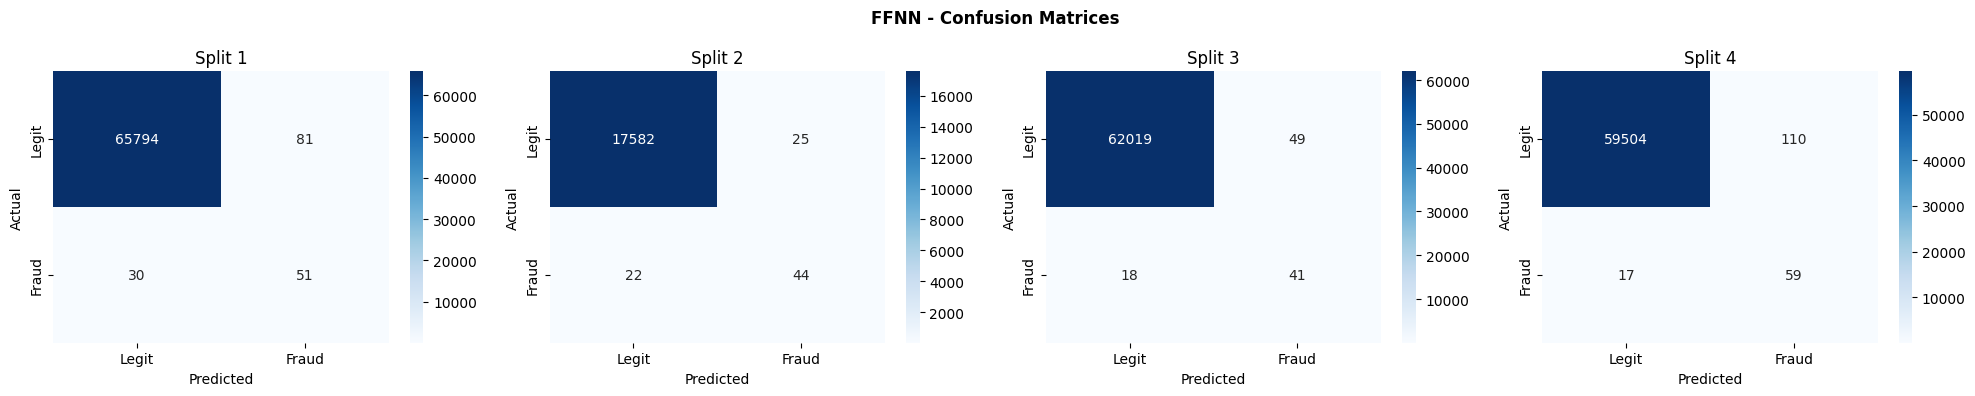

In [184]:
input_dim = Xfeatures.shape[1]
nn_results = []
split_predictions = {}
all_epoch_losses = {}

for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
  X_train_resampled, y_train_resampled, XtestScaled, y_testr = jscale_resample(Xfeatures, y, train_idx, test_idx)

  model, epoch_losses = _train_nn(X_train_resampled, y_train_resampled, input_dim)
  y_pred, y_prob = _predict(model, XtestScaled)
  metrics = compute_metrics(y_testr, y_pred, y_prob)
  metrics["split"] = split_num
  nn_results.append(metrics)
  split_predictions[split_num] = {"y_pred": y_pred, "y_prob": y_prob}
  all_epoch_losses[split_num] = epoch_losses

nn_results = pd.DataFrame(nn_results)

fig, ax = plt.subplots(figsize=(10,5))
color_splits = ["#056517", "#de1a24", "#3b75e9", "#cad5ed"]
for split_num in sorted(all_epoch_losses.keys()):
  losses = all_epoch_losses[split_num]
  color = color_splits[(split_num-1)%len(color_splits)]
  ax.plot(range(1, len(losses) +1), losses, label=f"Split {split_num}", color=color)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Over Epochs")
ax.legend()
save_fig(fig, "Training_Loss.png")
print(lr_results)
print(rf_df)
print(nn_results)
plot_metrics_bar(nn_results,splits, "FFNN", "FFNN_Metrics")
jplot_roc_curve(splits, Xfeatures, y, make_predictor("y_prob"), "FFNN", "FFNN_ROC_Curve")
jconfusion_matrices(splits, Xfeatures, y, make_predictor("y_pred"), "FFNN", "FFNN_Confusion_Matrix")

# Analysis

In [ ]:
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split as _tts

CRESULTS = "Cross_Dataset_Analysis"
os.makedirs(CRESULTS, exist_ok=True)

def _save_cross_fig(fig,name):
  path = os.path.join(CRESULTS, name)
  fig.savefig(path, bbox_inches="tight")
  plt.show()
  plt.close(fig)

def permutation_importance_auc(predict_proba_fn, X_test, y_test, n_repeats=5, random_state=42):
  rng = np.random.RandomState(random_state)
  X_arr = X_test.values if hasattr(X_test, "values") else np.asarray(X_test)
  y_arr = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)

  base_auc = roc_auc_score(y_arr, predict_proba_fn(X_arr))
  n_features = X_arr.shape[1]
  importances = np.zeros(n_features)

  for i in range(n_features):
    drops = []
    for _ in range(n_repeats):
      perm_arr = X_arr.copy()
      rng.shuffle(perm_arr[:, i])          # was: rng.shuffle(X.perm[:, i])
      perm_auc = roc_auc_score(y_arr, predict_proba_fn(perm_arr))
      drops.append(base_auc - perm_auc)
    importances[i] = np.mean(drops)
  return importances

def _nn_predict_proba_factory(model):
  def _proba(X_arr):
      model.eval()
      with torch.no_grad():
          X_t = torch.FloatTensor(X_arr).to(DEVICE)
          return model(X_t).cpu().numpy()
  return _proba

def extract_importances(X_features, y_labels, dataset_label, use_smote=True, test_size=0.25, nn_perm_repeats=5):
    """Train LR, RF, FFNN on one held-out split and return signed importance vectors."""
    feature_names = list(X_features.columns)

    # Convert to plain numpy upfront so downstream sklearn / imblearn / torch
    # never attempt attribute lookups on a pandas DataFrame (source of the
    # "'DataFrame' object has no attribute 'perm'" error).
    X_arr_full = np.asarray(X_features.values, dtype=np.float64)
    y_arr_full = np.asarray(y_labels.values if hasattr(y_labels, "values") else y_labels, dtype=np.int64)

    # Stratified split on numpy arrays.
    X_tr_raw, X_te_raw, y_tr, y_te = _tts(
        X_arr_full, y_arr_full,
        test_size=test_size, stratify=y_arr_full, random_state=RANDOM_STATE,
    )

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_raw)                  # numpy in -> numpy out
    X_te = scaler.transform(X_te_raw)

    # SMOTE only if requested; force numpy result regardless of imblearn version.
    if use_smote:
        sm = SMOTE(random_state=RANDOM_STATE)
        X_tr_bal, y_tr_bal = sm.fit_resample(X_tr, y_tr)
        X_tr_bal = np.asarray(X_tr_bal, dtype=np.float64)
        y_tr_bal = np.asarray(y_tr_bal, dtype=np.int64)
    else:
        X_tr_bal, y_tr_bal = X_tr, y_tr

    print(f"[{dataset_label}] train={len(X_tr_bal):,}  test={len(X_te):,}  features={len(feature_names)}")

    # Logistic Regression
    lr = _build_lr().fit(X_tr_bal, y_tr_bal)
    lr_signed = lr.coef_[0].astype(float)

    # Random Forest
    rf = _build_rf().fit(X_tr_bal, y_tr_bal)
    rf_imp = rf.feature_importances_.astype(float)

    # FFNN (BCELoss expects float targets)
    nn_model, _ = _train_nn(X_tr_bal, y_tr_bal.astype(np.float32), input_dim=len(feature_names))
    nn_perm = permutation_importance_auc(
        _nn_predict_proba_factory(nn_model), X_te, y_te,
        n_repeats=nn_perm_repeats, random_state=RANDOM_STATE,
    )

    return pd.DataFrame({
        "lr_signed": lr_signed,
        "lr_abs":    np.abs(lr_signed),
        "rf":        rf_imp,
        "nn_perm":   nn_perm,
    }, index=feature_names)

#Importances

In [185]:
X_d1 = df1.drop(columns=["isFraud"])
Y_d1 = df1["isFraud"].astype(int)
X_d2 = dset2_df.drop(columns=["Class"])
Y_d2 = dset2_df["Class"].astype(int)
X_d3 = Dataset3.drop(columns=["Class", "Time"], errors="ignore")
Y_d3 = Dataset3["Class"].astype(int)
print("Dataset 1 features:", X_d1.shape, " | fraud rate:", f"{Y_d1.mean()*100:.4f}%")
print("Dataset 2 features:", X_d2.shape, " | fraud rate:", f"{Y_d2.mean()*100:.4f}%")
print("Dataset 3 features:", X_d3.shape, " | fraud rate:", f"{Y_d3.mean()*100:.4f}%")
imp_d1 = extract_importances(X_d1, Y_d1, "Dataset 1 (PaySim)", use_smote=True)
imp_d2 = extract_importances(X_d2, Y_d2, "Dataset 2 (CC2023)", use_smote=False)
imp_d3 = extract_importances(X_d3, Y_d3, "Dataset 3 (CC2013)", use_smote=True)
imp_d1.to_csv(os.path.join(CRESULTS, "importances_d1.csv"))
imp_d2.to_csv(os.path.join(CRESULTS, "importances_d2.csv"))
imp_d3.to_csv(os.path.join(CRESULTS, "importances_d3.csv"))

Dataset 1 features: (500000, 16)  | fraud rate: 0.1294%
Dataset 2 features: (499999, 29)  | fraud rate: 50.0165%
Dataset 3 features: (283726, 29)  | fraud rate: 0.1667%
[Dataset 1 (PaySim)] train=749,030  test=125,000  features=16
Epoch   1/50  |  Loss: 0.106104
Epoch  10/50  |  Loss: 0.048778
Epoch  20/50  |  Loss: 0.044832
Epoch  30/50  |  Loss: 0.042690
Epoch  40/50  |  Loss: 0.044836
Epoch  50/50  |  Loss: 0.043593
[Dataset 2 (CC2023)] train=374,999  test=125,000  features=29
Epoch   1/50  |  Loss: 0.080642
Epoch  10/50  |  Loss: 0.017820
Epoch  20/50  |  Loss: 0.015898
Epoch  30/50  |  Loss: 0.015000
Epoch  40/50  |  Loss: 0.015341
Epoch  50/50  |  Loss: 0.014667
[Dataset 3 (CC2013)] train=424,878  test=70,932  features=29
Epoch   1/50  |  Loss: 0.091421
Epoch  10/50  |  Loss: 0.019043
Epoch  20/50  |  Loss: 0.014982
Epoch  30/50  |  Loss: 0.013904
Epoch  40/50  |  Loss: 0.013955
Epoch  50/50  |  Loss: 0.013089


Within Dataset Consensus


=== Dataset 1 - Top 10 by consensus rank ===
                         rank_LR  rank_RF  rank_NN  mean_rank  lr_sign
balance_change_orig          4.0      1.0      3.0       2.67     -1.0
amount_to_balance_ratio      5.0      2.0      6.0       4.33     -1.0
newbalanceOrig               1.0      3.0     11.0       5.00     -1.0
oldbalanceOrg                2.0      4.0     12.0       6.00     -1.0
log_oldbalance_orig         12.0      5.0      2.0       6.33      1.0
amount_to_avg_ratio          7.0      8.0      9.0       8.00     -1.0
amount                       6.0     10.0      8.0       8.00     -1.0
balance_change_dest          3.0     12.0     10.0       8.33     -1.0
log_amount                  14.0     11.0      1.0       8.67     -1.0
type_amount_interaction     15.0      6.0      7.0       9.33      1.0

=== Dataset 2 - Top 10 by consensus rank ===
     rank_LR  rank_RF  rank_NN  mean_rank  lr_sign
V14      2.0      1.0      1.0       1.33     -1.0
V12      4.0      3.0    

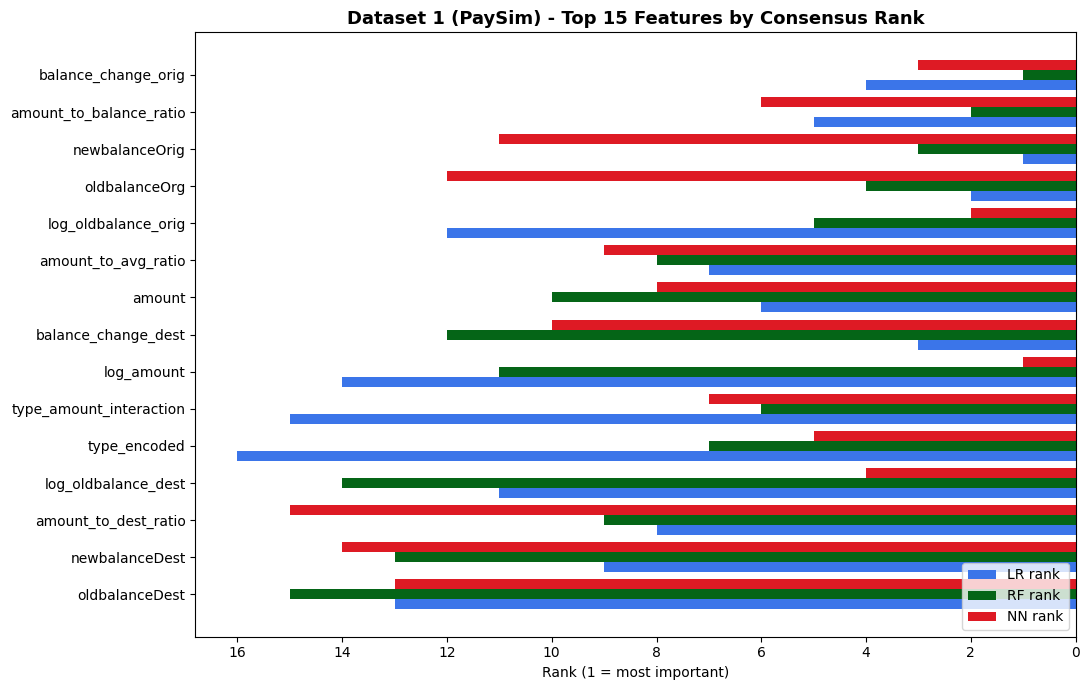

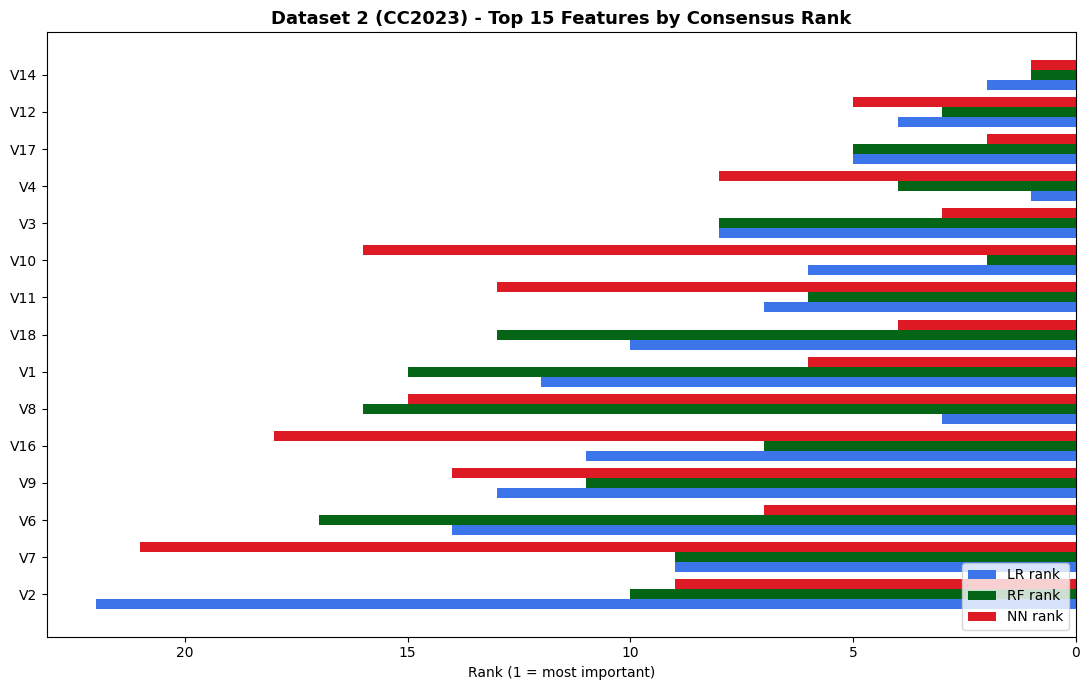

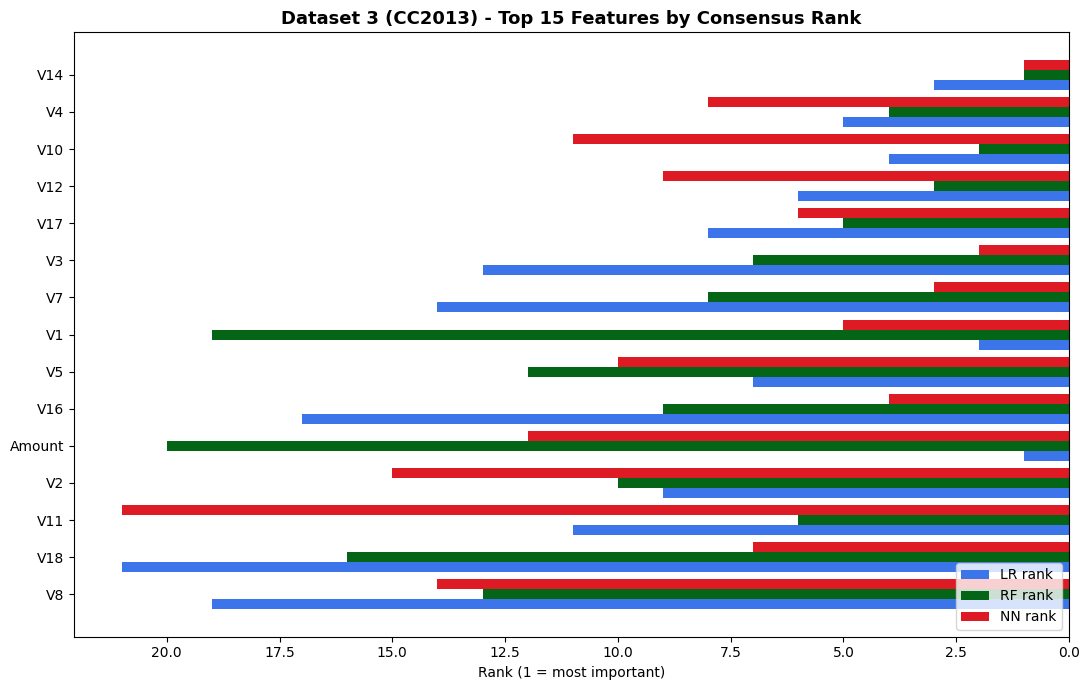

Shared feature count: 29

=== Spearman rank correlation: Dataset 2 vs Dataset 3 (V1-V28 + Amount) ===
                     spearman_rho  p_value
Logistic Regression        0.3749   0.0451
Random Forest              0.9557   0.0000
Feed-Forward NN            0.6818   0.0000


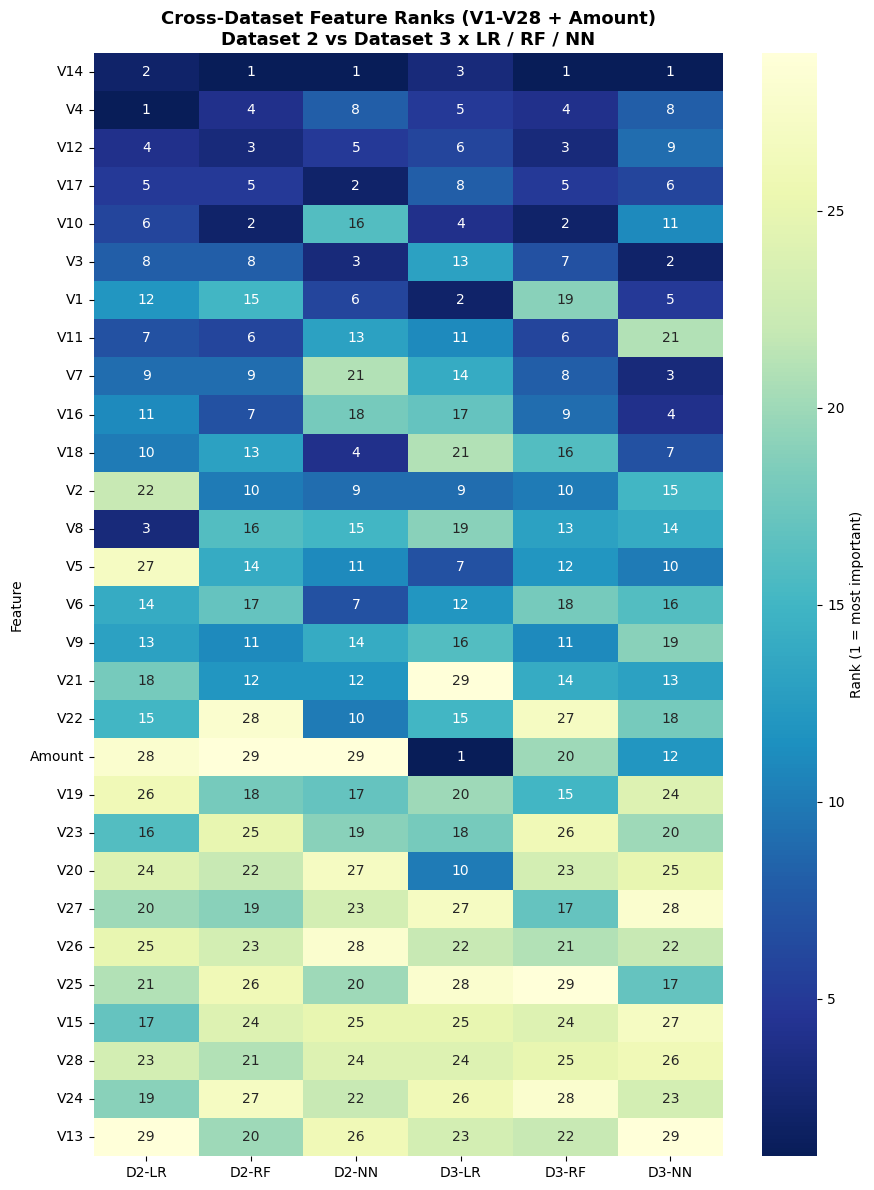


Universal fraud-indicative features (top-10 in BOTH datasets under BOTH LR & RF):
     lr_sign_D2  lr_sign_D3  rf_imp_D2  rf_imp_D3  agree_direction
V10          -1          -1     0.1501     0.1485             True
V12          -1          -1     0.1259     0.1222             True
V14          -1          -1     0.1761     0.1730             True
V17          -1          -1     0.0865     0.0804             True
V4            1           1     0.1213     0.0959             True


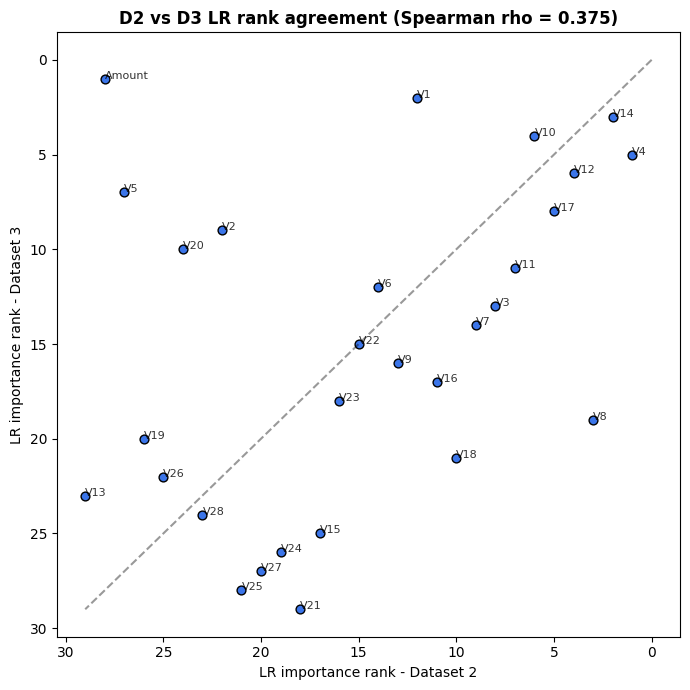

In [186]:
def build_consensus(imp_df):
  ranks = pd.DataFrame({
      "rank_LR":   imp_df["lr_abs"].rank(method="average", ascending=False),
      "rank_RF":   imp_df["rf"].rank(method="average", ascending=False),
      "rank_NN":   imp_df["nn_perm"].rank(method="average", ascending=False),
  }, index=imp_df.index)
  ranks["mean_rank"] = ranks.mean(axis=1)
  ranks["lr_sign"]   = np.sign(imp_df["lr_signed"])
  return ranks.sort_values("mean_rank")


consensus_d1 = build_consensus(imp_d1)
consensus_d2 = build_consensus(imp_d2)
consensus_d3 = build_consensus(imp_d3)
consensus_d1.to_csv(os.path.join(CRESULTS, "consensus_d1.csv"))
consensus_d2.to_csv(os.path.join(CRESULTS, "consensus_d2.csv"))
consensus_d3.to_csv(os.path.join(CRESULTS, "consensus_d3.csv"))
print("\n=== Dataset 1 - Top 10 by consensus rank ===")
print(consensus_d1.head(10).round(2))
print("\n=== Dataset 2 - Top 10 by consensus rank ===")
print(consensus_d2.head(10).round(2))
print("\n=== Dataset 3 - Top 10 by consensus rank ===")
print(consensus_d3.head(10).round(2))

def plot_consensus_topk(consensus_df, dataset_name, filename, top_k=15):
  top = consensus_df.head(top_k).iloc[::-1]
  fig, ax = plt.subplots(figsize=(11, 7))
  y_pos = np.arange(len(top))
  width = 0.27
  ax.barh(y_pos - width, top["rank_LR"], width, label="LR rank",  color="#3b75e9")
  ax.barh(y_pos,         top["rank_RF"], width, label="RF rank",  color="#056517")
  ax.barh(y_pos + width, top["rank_NN"], width, label="NN rank",  color="#de1a24")
  ax.set_yticks(y_pos)
  ax.set_yticklabels(top.index)
  ax.set_xlabel("Rank (1 = most important)")
  ax.set_title(f"{dataset_name} - Top {top_k} Features by Consensus Rank",
                fontsize=13, fontweight="bold")
  ax.invert_xaxis()
  ax.legend(loc="lower right")
  fig.tight_layout()
  _save_cross_fig(fig, filename)


plot_consensus_topk(consensus_d1, "Dataset 1 (PaySim)",  "d1_within_consensus.png")
plot_consensus_topk(consensus_d2, "Dataset 2 (CC2023)",  "d2_within_consensus.png")
plot_consensus_topk(consensus_d3, "Dataset 3 (CC2013)",  "d3_within_consensus.png")


shared_features = [f"V{i}" for i in range(1, 29)] + ["Amount"]
shared_features = [f for f in shared_features if f in imp_d2.index and f in imp_d3.index]
print(f"Shared feature count: {len(shared_features)}")

imp_d2_shared = imp_d2.loc[shared_features]
imp_d3_shared = imp_d3.loc[shared_features]


spearman_results = {}
for col, label in [("lr_abs", "Logistic Regression"),
                   ("rf",     "Random Forest"),
                   ("nn_perm","Feed-Forward NN")]:
    rho, pval = spearmanr(imp_d2_shared[col], imp_d3_shared[col])
    spearman_results[label] = {"spearman_rho": rho, "p_value": pval}

spearman_df = pd.DataFrame(spearman_results).T
print("\n=== Spearman rank correlation: Dataset 2 vs Dataset 3 (V1-V28 + Amount) ===")
print(spearman_df.round(4))
spearman_df.to_csv(os.path.join(CRESULTS, "spearman_d2_vs_d3.csv"))


def _ranks(df, col):
    return df[col].rank(method="average", ascending=False)

rank_table = pd.DataFrame({
    ("D2", "LR"): _ranks(imp_d2_shared, "lr_abs"),
    ("D2", "RF"): _ranks(imp_d2_shared, "rf"),
    ("D2", "NN"): _ranks(imp_d2_shared, "nn_perm"),
    ("D3", "LR"): _ranks(imp_d3_shared, "lr_abs"),
    ("D3", "RF"): _ranks(imp_d3_shared, "rf"),
    ("D3", "NN"): _ranks(imp_d3_shared, "nn_perm"),
})
rank_table.columns = pd.MultiIndex.from_tuples(rank_table.columns, names=["dataset", "model"])

rank_table["__mean__"] = rank_table.mean(axis=1)
rank_table = rank_table.sort_values("__mean__")
mean_col = rank_table.pop("__mean__")

rank_table.to_csv(os.path.join(CRESULTS, "cross_dataset_rank_table.csv"))


fig, ax = plt.subplots(figsize=(9, 12))
sns.heatmap(
    rank_table.values,
    annot=True, fmt=".0f",
    cmap="YlGnBu_r",
    yticklabels=rank_table.index,
    xticklabels=[f"{ds}-{m}" for ds, m in rank_table.columns],
    cbar_kws={"label": "Rank (1 = most important)"},
    ax=ax,
)
ax.set_title("Cross-Dataset Feature Ranks (V1-V28 + Amount)\nDataset 2 vs Dataset 3 x LR / RF / NN",
             fontsize=13, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("Feature")
fig.tight_layout()
_save_cross_fig(fig, "cross_dataset_rank_heatmap.png")

TOP_K = 10

def _topk_set(df, col, k=TOP_K):
    return set(df[col].sort_values(ascending=False).head(k).index)

universal = (
    _topk_set(imp_d2_shared, "lr_abs")
    & _topk_set(imp_d2_shared, "rf")
    & _topk_set(imp_d3_shared, "lr_abs")
    & _topk_set(imp_d3_shared, "rf")
)

direction_table = pd.DataFrame({
    "lr_sign_D2": np.sign(imp_d2_shared.loc[sorted(universal), "lr_signed"]).astype(int),
    "lr_sign_D3": np.sign(imp_d3_shared.loc[sorted(universal), "lr_signed"]).astype(int),
    "rf_imp_D2":  imp_d2_shared.loc[sorted(universal), "rf"].round(4),
    "rf_imp_D3":  imp_d3_shared.loc[sorted(universal), "rf"].round(4),
})
direction_table["agree_direction"] = direction_table["lr_sign_D2"] == direction_table["lr_sign_D3"]

print(f"\nUniversal fraud-indicative features (top-{TOP_K} in BOTH datasets under BOTH LR & RF):")
print(direction_table)
direction_table.to_csv(os.path.join(CRESULTS, "universal_features.csv"))

# Quick scatter: LR-importance rank D2 vs D3 to visualise the rank correlation.
fig, ax = plt.subplots(figsize=(7, 7))
r2_lr = imp_d2_shared["lr_abs"].rank(ascending=False)
r3_lr = imp_d3_shared["lr_abs"].rank(ascending=False)
ax.scatter(r2_lr, r3_lr, s=40, color="#3b75e9", edgecolor="black")
for feat in shared_features:
    ax.annotate(feat, (r2_lr[feat], r3_lr[feat]), fontsize=8, alpha=0.8)
ax.plot([0, len(shared_features)], [0, len(shared_features)], "k--", alpha=0.4)
ax.set_xlabel("LR importance rank - Dataset 2")
ax.set_ylabel("LR importance rank - Dataset 3")
ax.set_title(f"D2 vs D3 LR rank agreement (Spearman rho = "
             f"{spearman_results['Logistic Regression']['spearman_rho']:.3f})",
             fontsize=12, fontweight="bold")
ax.invert_xaxis(); ax.invert_yaxis()                       # Top-right corner = important in both
fig.tight_layout()
_save_cross_fig(fig, "d2_vs_d3_lr_rank_scatter.png")